# Regional Sales Breakdown

**Goal:** compare video game sales across four regions — **North America**, **Europe**, **Japan** and **Other** — by genre, platform, publisher, release year and top games.

**Data:** `vgsales.csv`, 16,598 rows × 11 columns (one row = one game on one platform). All sales values are in **millions of units**, not USD.

## Libraries

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

print('All libraries are ready to use.')

All libraries are ready to use.


## Data overview and first look

In [2]:
data = pd.read_csv('../data/vgsales.csv')
print('Data is ready.')

Data is ready.


In [3]:
n_columns = data.shape[1]
n_rows = data.shape[0]

print(f'There are {n_columns} columns and {n_rows} rows in the Video Game Sales dataset.')

There are 11 columns and 16598 rows in the Video Game Sales dataset.


In [4]:
data.columns.to_list()

['Rank',
 'Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

In [5]:
data.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [7]:
data.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [8]:
data.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
2561,2563,NCAA Football 14,PS3,2013.0,Sports,Electronic Arts,0.75,0.00,0.0,0.06,0.80
5791,5793,NHL FaceOff 2000,PS,1998.0,Sports,Sony Computer Entertainment,0.17,0.12,0.0,0.02,0.31
6639,6641,Spy Kids Challenger,GBA,2002.0,Platform,Disney Interactive Studios,0.18,0.07,0.0,0.00,0.25
4758,4760,Naughty Bear,X360,2010.0,Action,505 Games,0.21,0.16,0.0,0.04,0.41
16233,16236,Marvel: Ultimate Alliance,PC,2006.0,Role-Playing,Activision,0.01,0.00,0.0,0.00,0.01


In [9]:
data.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [10]:
data.nunique()

Rank            16598
Name            11493
Platform           31
Year               39
Genre              12
Publisher         578
NA_Sales          409
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      623
dtype: int64

## Cleaning

### Overall

In [11]:
data.columns = data.columns.str.lower()
data.columns.to_list()

['rank',
 'name',
 'platform',
 'year',
 'genre',
 'publisher',
 'na_sales',
 'eu_sales',
 'jp_sales',
 'other_sales',
 'global_sales']

In [12]:
missing_values = data.isnull().sum()
missing_pct = (missing_values / len(data) * 100).round(1)

missing_summary = pd.DataFrame({'missing_count': missing_values, 'missing_%': missing_pct})

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_%
year,271,1.6
publisher,58,0.3


**Only 2 columns have missing values: `year` (271 rows, 1.6%) and `publisher` (58 rows, 0.3%)**

- `publisher` is filled with `unknown`, so those games stay in every regional total
- `year` is **not** filled. A made-up year would break the time analysis, so these rows are only left out of the year-based section

In [13]:
data['publisher'] = data['publisher'].fillna('unknown')

data['publisher'].isnull().sum()

np.int64(0)

`publisher` has no missing values now. `year` still has 271 missing values on purpose.

### Duplicates

In [14]:
dup_counts = data.duplicated().sum()
print(f'Total duplicates count: {dup_counts}')

dup_game_platform = data.duplicated(subset=['name', 'platform']).sum()
print(f'Rows with repeated name + platform: {dup_game_platform}')

Total duplicates count: 0
Rows with repeated name + platform: 5


In [15]:
repeated_pairs = data[data.duplicated(subset=['name', 'platform'], keep=False)].sort_values(['name', 'platform'])
repeated_pairs

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
603,604,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,2.11,0.23,0.00,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01
5900,5902,Need for Speed: Most Wanted,PC,2005.0,Racing,Electronic Arts,0.02,0.23,0.00,0.05,0.30
11676,11678,Need for Speed: Most Wanted,PC,2012.0,Racing,Electronic Arts,0.00,0.06,0.00,0.02,0.08
1173,1175,Need for Speed: Most Wanted,X360,2012.0,Racing,Electronic Arts,0.62,0.80,0.01,0.15,1.58
1530,1532,Need for Speed: Most Wanted,X360,2005.0,Racing,Electronic Arts,1.00,0.17,0.02,0.10,1.29
1715,1717,Sonic the Hedgehog,PS3,2006.0,Platform,Sega,0.41,0.07,0.04,0.66,1.18
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,unknown,0.00,0.48,0.00,0.00,0.48
14997,15000,Wii de Asobu: Metroid Prime,Wii,NaN,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02
14999,15002,Wii de Asobu: Metroid Prime,Wii,NaN,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02


There are no fully duplicated rows.

5 `name` + `platform` pairs repeat (10 rows, 7.52M of `global_sales`, 0.08% of the total). Their `rank`, `year` or sales values differ, so they are not exact copies. Some are separate releases (`Need for Speed: Most Wanted`, 2005 vs 2012). Others (`Madden NFL 13` with a 0.01M row, `Sonic the Hedgehog` with a missing year) may be a second record of the same release, which this file cannot prove.

All are kept, because their combined effect is below 0.1% of sales.

### Sales columns check

In [16]:
row_diff = (data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1) - data['global_sales']).abs()
print(f'Biggest row-level gap between the 4 regions and global_sales: {row_diff.max():.2f}')

regions_sum = data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum().sum()
global_sum = data['global_sales'].sum()
print(f'Sum of 4 regions: {regions_sum:,.2f}M | global_sales column: {global_sum:,.2f}M | Difference: {global_sum - regions_sum:,.2f}M')

Biggest row-level gap between the 4 regions and global_sales: 0.02


Sum of 4 regions: 8,915.85M | global_sales column: 8,920.44M | Difference: 4.59M


In [17]:
sales_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
gap = data['global_sales'] - data[sales_cols].sum(axis=1)

print(f'Rows where global_sales > 4-region sum : {(gap > 0.001).sum():,} (total gap: {gap[gap > 0.001].sum():+.2f}M)')
print(f'Rows where global_sales < 4-region sum : {(gap < -0.001).sum():,} (total gap: {gap[gap < -0.001].sum():+.2f}M)')

all_zero = (data[sales_cols].sum(axis=1) == 0) & (data['global_sales'] > 0)
print(f'Rows with all 4 regions = 0.00 but global_sales > 0 : {all_zero.sum():,} '
      f'(their global_sales total: {data.loc[all_zero, "global_sales"].sum():.2f}M)')

Rows where global_sales > 4-region sum : 2,484 (total gap: +24.90M)
Rows where global_sales < 4-region sum : 2,027 (total gap: -20.31M)
Rows with all 4 regions = 0.00 but global_sales > 0 : 1 (their global_sales total: 0.01M)


The 4 regions add up to `global_sales` with a small gap: at most 0.02 per row, and 4.59M in total (about 0.05%).

The gap goes **both ways**: `global_sales` is higher in 2,484 rows (+24.90M) and lower in 2,027 rows (−20.31M), so the net 4.59M is a small remainder of two opposite differences. Only 1 row has all four regions at `0.00` while `global_sales` is above 0 (0.01M), so that does not explain it. The cause is not visible in this file, and at 0.05% it does not change any result.

For this reason, all regional shares below use **the sum of the 4 regions** as 100%, so the shares always add up to 100%.

### Years

In [18]:
data['year'].value_counts().sort_index().tail(8)

year
2011.0    1139
2012.0     657
2013.0     546
2014.0     582
2015.0     614
2016.0     344
2017.0       3
2020.0       1
Name: count, dtype: int64

**IMPORTANT** — The last years are not complete: 2016 has 344 games (2015 has 614), and 2017 and 2020 have only 3 and 1 games.

The year-based section uses only **1980–2015**, so an incomplete year is not read as a real drop in sales.

### Region setup

The 4 region columns, their display names and colors are defined once here and used in all sections below.

In [19]:
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

region_names = {
    'na_sales': 'North America',
    'eu_sales': 'Europe',
    'jp_sales': 'Japan',
    'other_sales': 'Other'
}

region_labels = list(region_names.values())

region_colors = {
    'North America': '#2E86AB',
    'Europe': '#F26419',
    'Japan': '#A23B72',
    'Other': '#7F7F7F'
}

print(region_labels)

['North America', 'Europe', 'Japan', 'Other']


## Regional statistics

### Total sales by region

In [20]:
region_total = data[regions].sum().reset_index()
region_total.columns = ['region_column', 'total_sales']

region_total['region'] = region_total['region_column'].map(region_names)
region_total['share_pct'] = (region_total['total_sales'] / region_total['total_sales'].sum() * 100).round(1)

region_total = region_total[['region', 'total_sales', 'share_pct']].round(1)
region_total

,region,total_sales,share_pct
0,North America,4393.0,49.3
1,Europe,2434.1,27.3
2,Japan,1291.0,14.5
3,Other,797.8,8.9


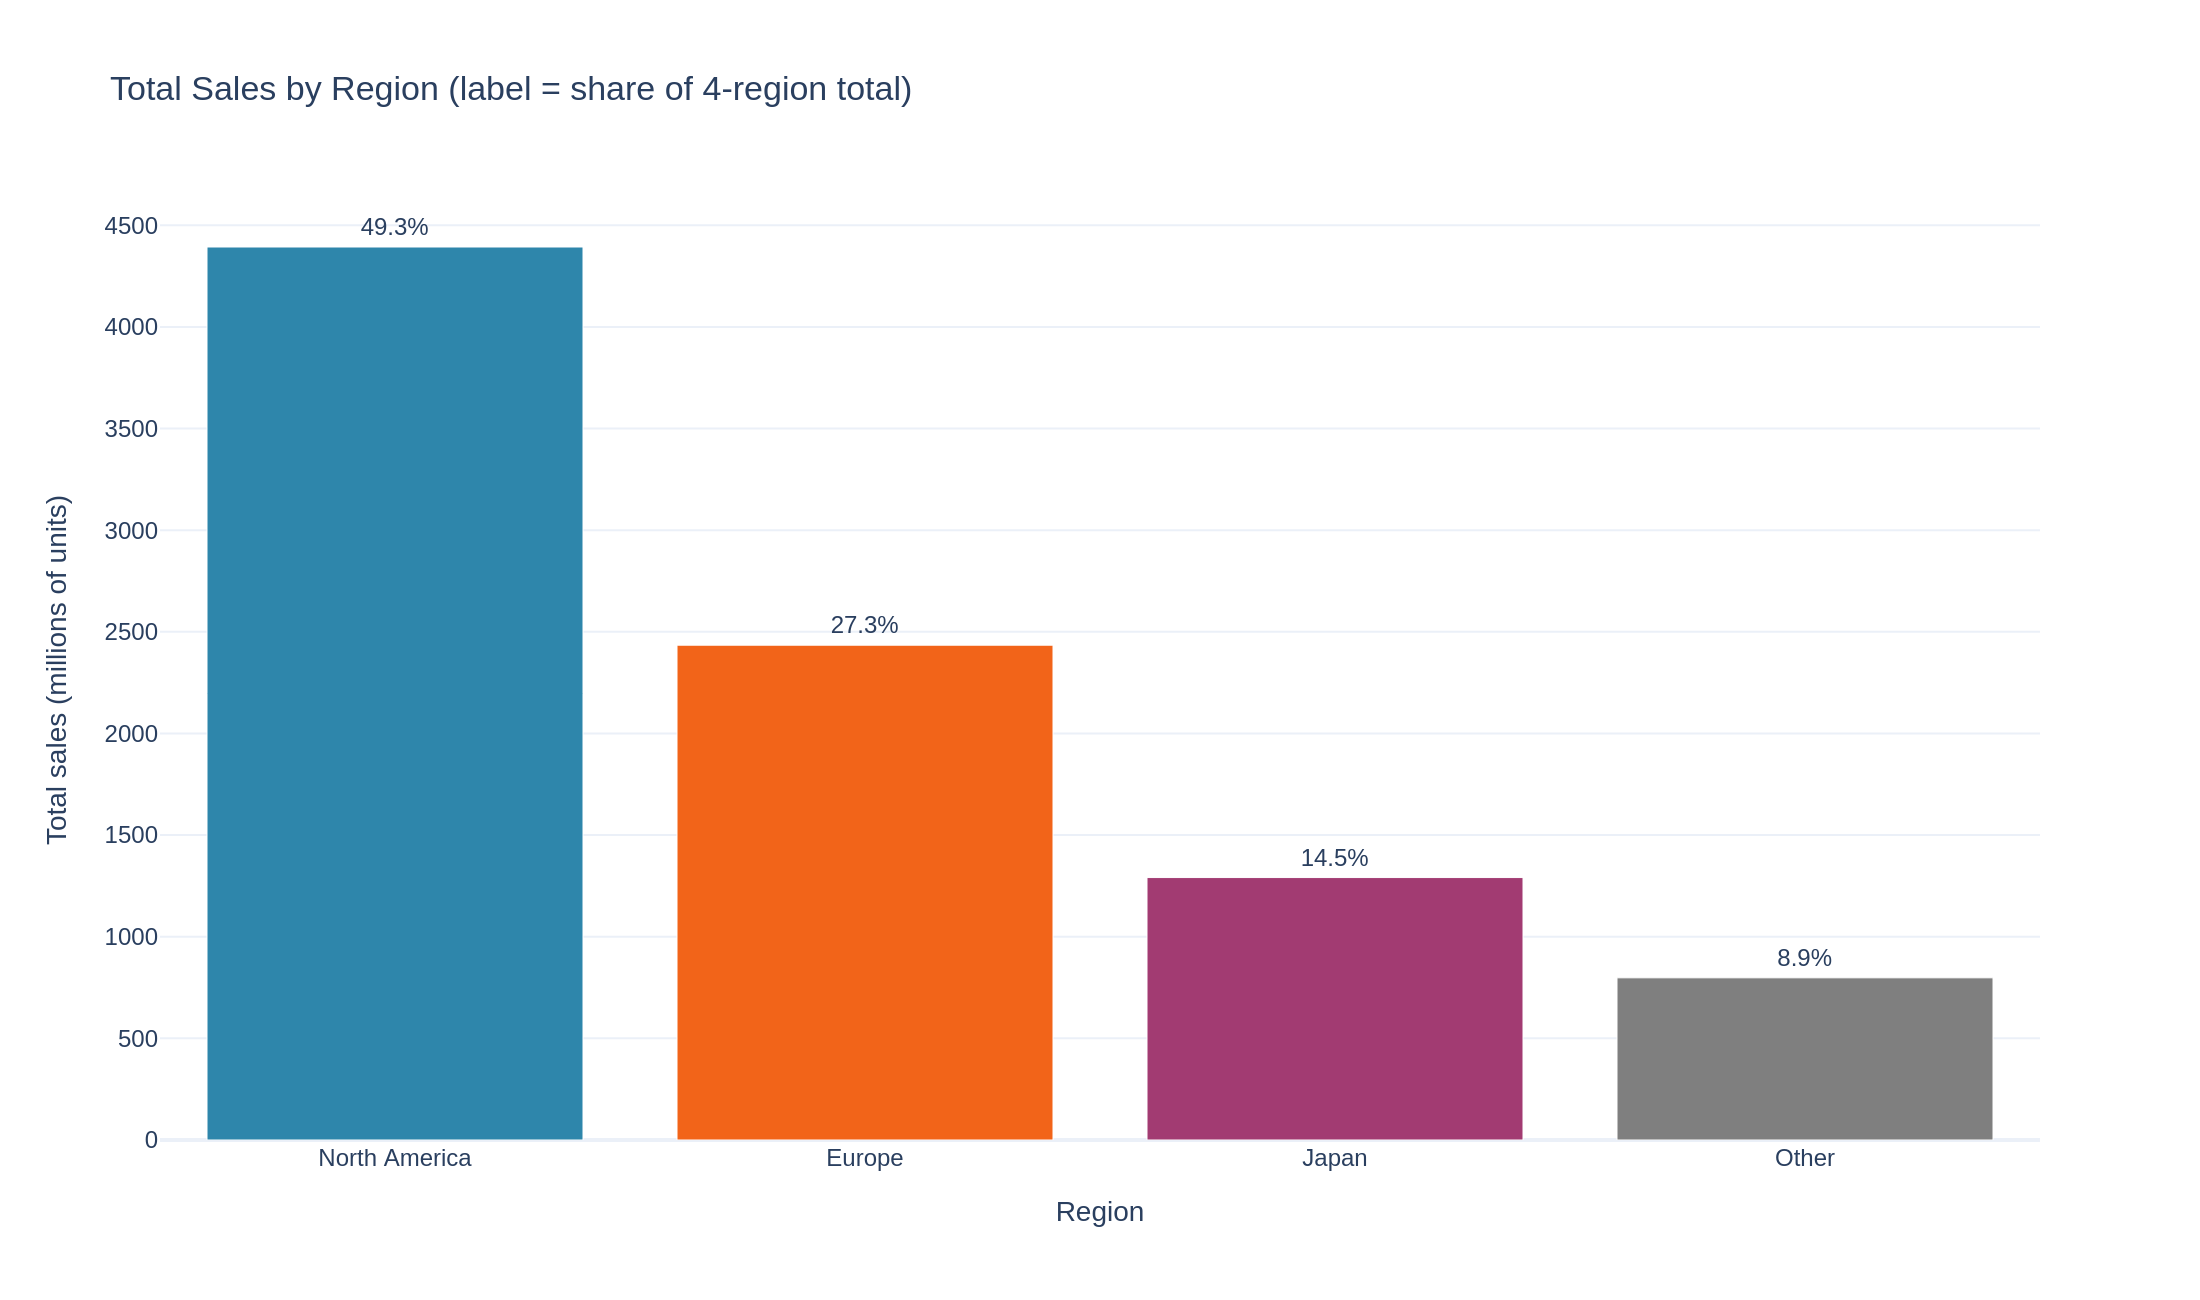

In [21]:
fig_region = px.bar(
    region_total,
    x='region',
    y='total_sales',
    color='region',
    color_discrete_map=region_colors,
    text='share_pct',
    title='Total Sales by Region (label = share of 4-region total)',
    labels={'region': 'Region', 'total_sales': 'Total sales (millions of units)'}
)

fig_region.update_traces(texttemplate='%{text}%', textposition='outside')
fig_region.update_layout(template='plotly_white', showlegend=False)
fig_region.show()

**Result** — North America is the biggest market with **49.3%** of sales (4,393.0M units), then Europe with **27.3%**, Japan with **14.5%** and Other with **8.9%**.

North America's sales are about 1.8 times Europe's and 3.4 times Japan's.

### Sales per game

In [22]:
region_stats = pd.DataFrame({
    'total_sales': data[regions].sum(),
    'mean_per_game': data[regions].mean(),
    'median_per_game': data[regions].median(),
    'zero_sales_pct': (data[regions] == 0).mean() * 100
}).round(2)

region_stats = region_stats.rename(index=region_names)
region_stats

,total_sales,mean_per_game,median_per_game,zero_sales_pct
North America,4392.95,0.26,0.08,27.11
Europe,2434.13,0.15,0.02,34.52
Japan,1291.02,0.08,0.00,62.99
Other,797.75,0.05,0.01,39.02


`mean_per_game` is much higher than `median_per_game` in every region, so sales are **right-skewed**: a few hits sell a lot and most games sell very little.

`zero_sales_pct` is the share of games recorded as `0.00` in that region (very small sales, rounded to zero).

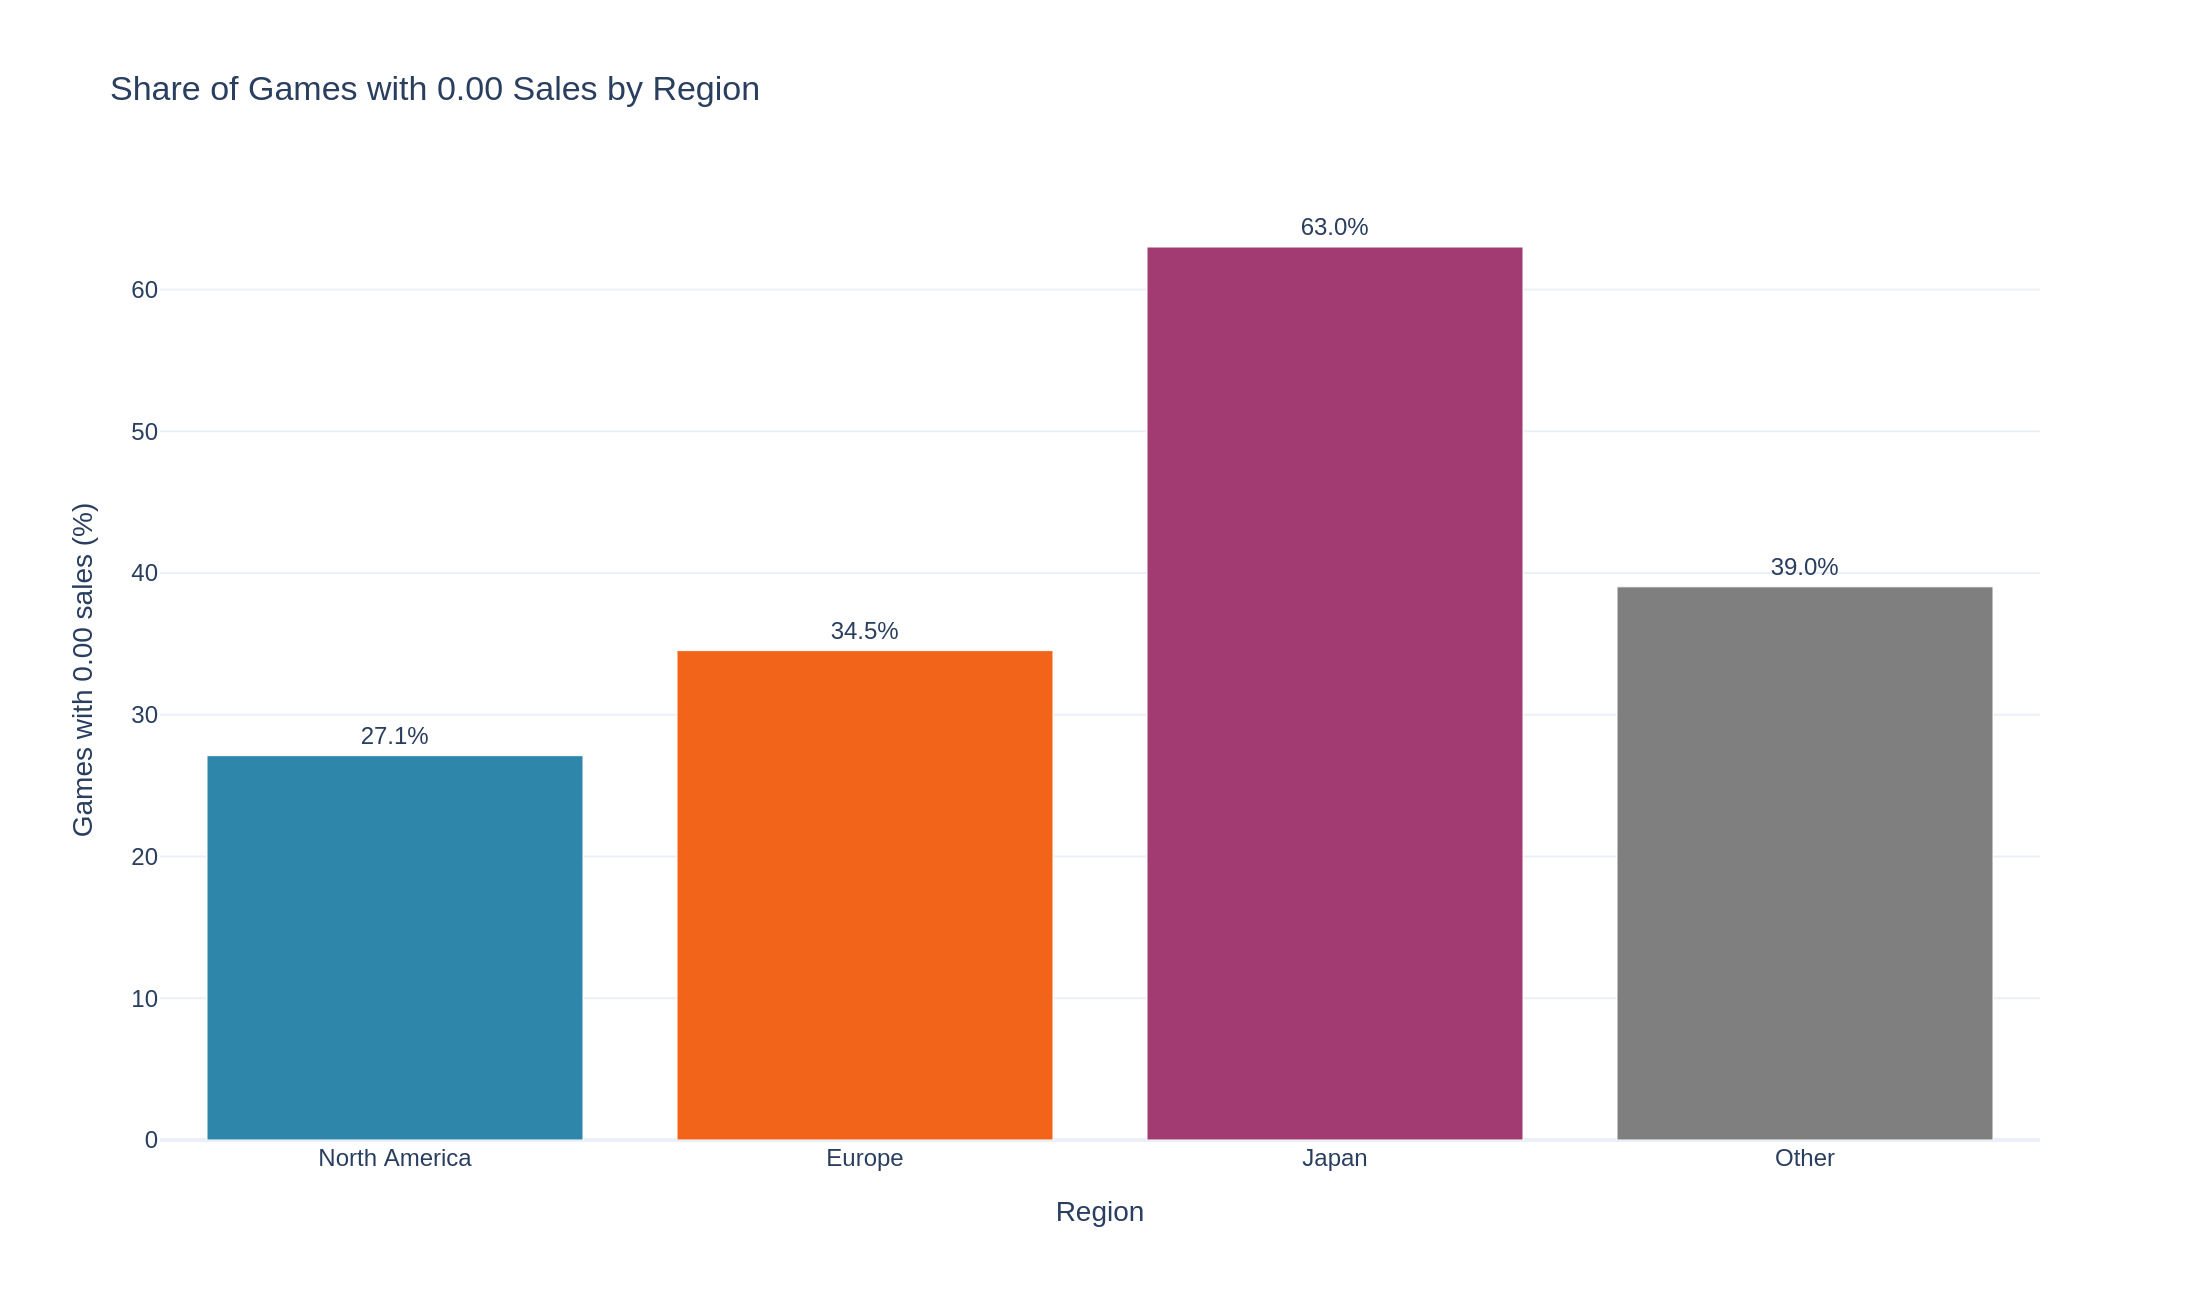

In [23]:
region_stats.index.name = 'region'

fig_zero = px.bar(
    region_stats.reset_index(),
    x='region',
    y='zero_sales_pct',
    color='region',
    color_discrete_map=region_colors,
    text='zero_sales_pct',
    title='Share of Games with 0.00 Sales by Region',
    labels={'region': 'Region', 'zero_sales_pct': 'Games with 0.00 sales (%)'}
)

fig_zero.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig_zero.update_layout(template='plotly_white', showlegend=False)
fig_zero.show()

**Result** — In Japan **63.0%** of the games in the dataset have `0.00` sales (below 5,000 units), compared with 27.1% in North America.

The data cannot say why. These games may not have been released in Japan at all, or they may have been released and sold very little. Release-region data would be needed to separate the two, so this is a fact about the dataset, not yet a statement about how selective the Japanese market is.

## Genre by region

In [24]:
genre_region = data.groupby('genre')[regions].sum().rename(columns=region_names)

genre_region['total'] = genre_region.sum(axis=1)
genre_region = genre_region.sort_values('total', ascending=False)

genre_region.round(1)

,North America,Europe,Japan,Other,total
genre,,,,,
Action,877.8,525.0,160.0,187.4,1750.2
Sports,683.4,376.8,135.4,135.0,1330.5
Shooter,582.6,313.3,38.3,102.7,1036.8
Role-Playing,327.3,188.1,352.3,59.6,927.3
Platform,447.0,201.6,130.8,51.6,831.0
Misc,410.2,216.0,107.8,75.3,809.3
Racing,359.4,238.4,56.7,77.3,731.8
Fighting,223.6,101.3,87.4,36.7,448.9
Simulation,183.3,113.4,63.7,31.5,391.9


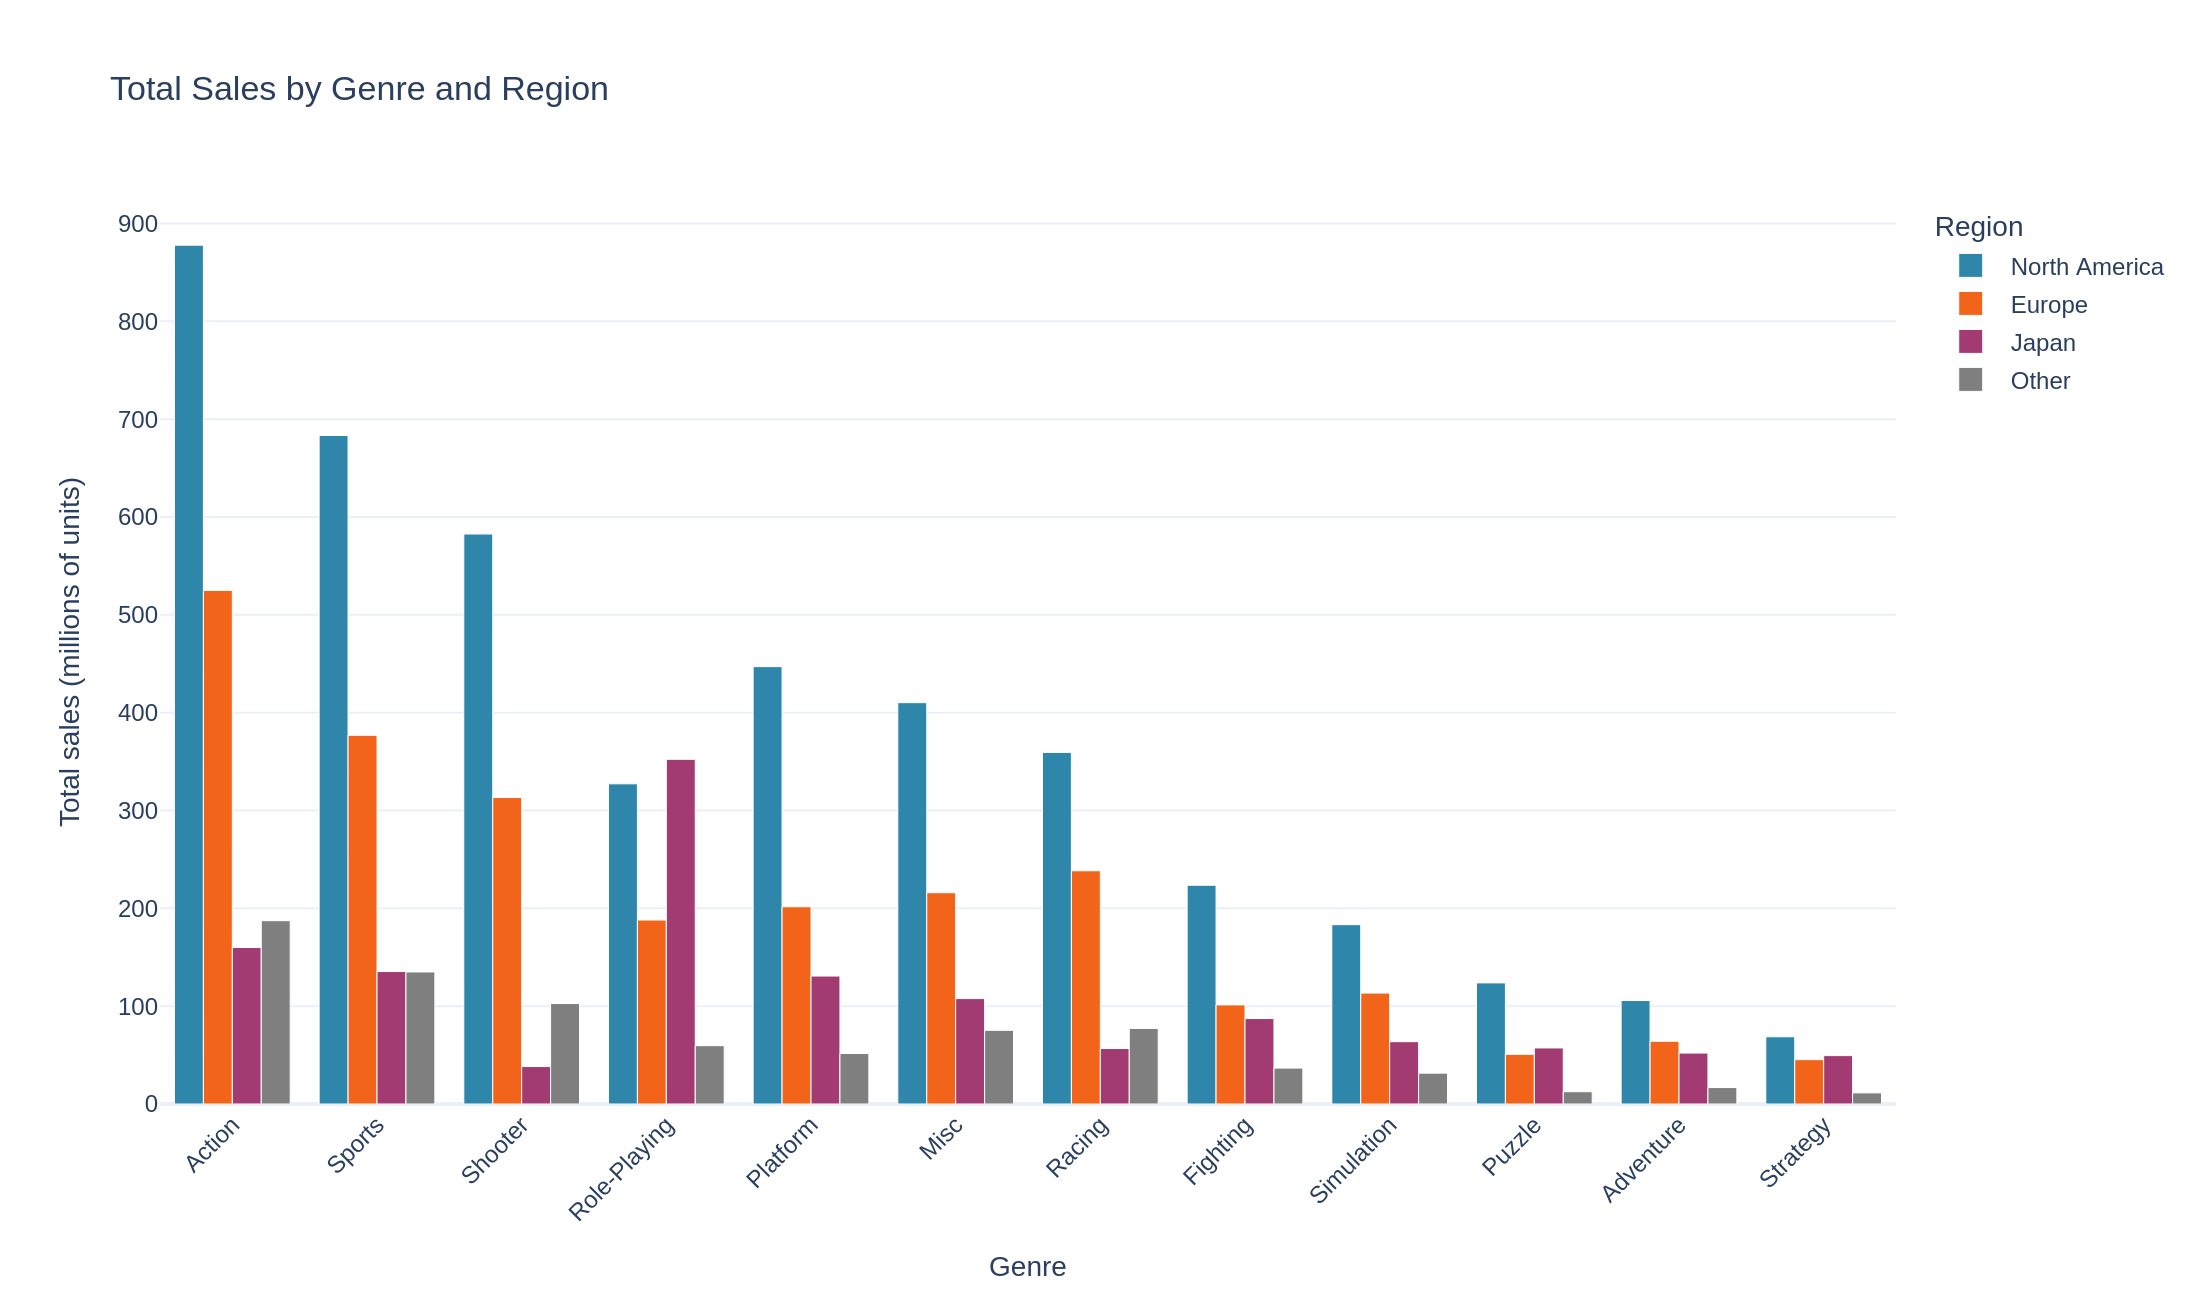

In [25]:
genre_long = genre_region[region_labels].reset_index().melt(id_vars='genre', var_name='region', value_name='sales')

fig_genre = px.bar(
    genre_long,
    x='genre',
    y='sales',
    color='region',
    barmode='group',
    color_discrete_map=region_colors,
    category_orders={'genre': genre_region.index.tolist()},
    title='Total Sales by Genre and Region',
    labels={'genre': 'Genre', 'sales': 'Total sales (millions of units)', 'region': 'Region'}
)

fig_genre.update_layout(template='plotly_white', xaxis_tickangle=-45)
fig_genre.show()

Action, Sports and Shooter together are 4,117.5M units, **46.2%** of all sales, so three genres carry almost half of the market.

Absolute numbers are mostly driven by the size of each market. To compare **taste**, the next step shows the genre share inside each region.

In [26]:
genre_share = genre_region[region_labels] / genre_region[region_labels].sum() * 100

genre_share.round(1)

,North America,Europe,Japan,Other
genre,,,,
Action,20.0,21.6,12.4,23.5
Sports,15.6,15.5,10.5,16.9
Shooter,13.3,12.9,3.0,12.9
Role-Playing,7.5,7.7,27.3,7.5
Platform,10.2,8.3,10.1,6.5
Misc,9.3,8.9,8.3,9.4
Racing,8.2,9.8,4.4,9.7
Fighting,5.1,4.2,6.8,4.6
Simulation,4.2,4.7,4.9,4.0


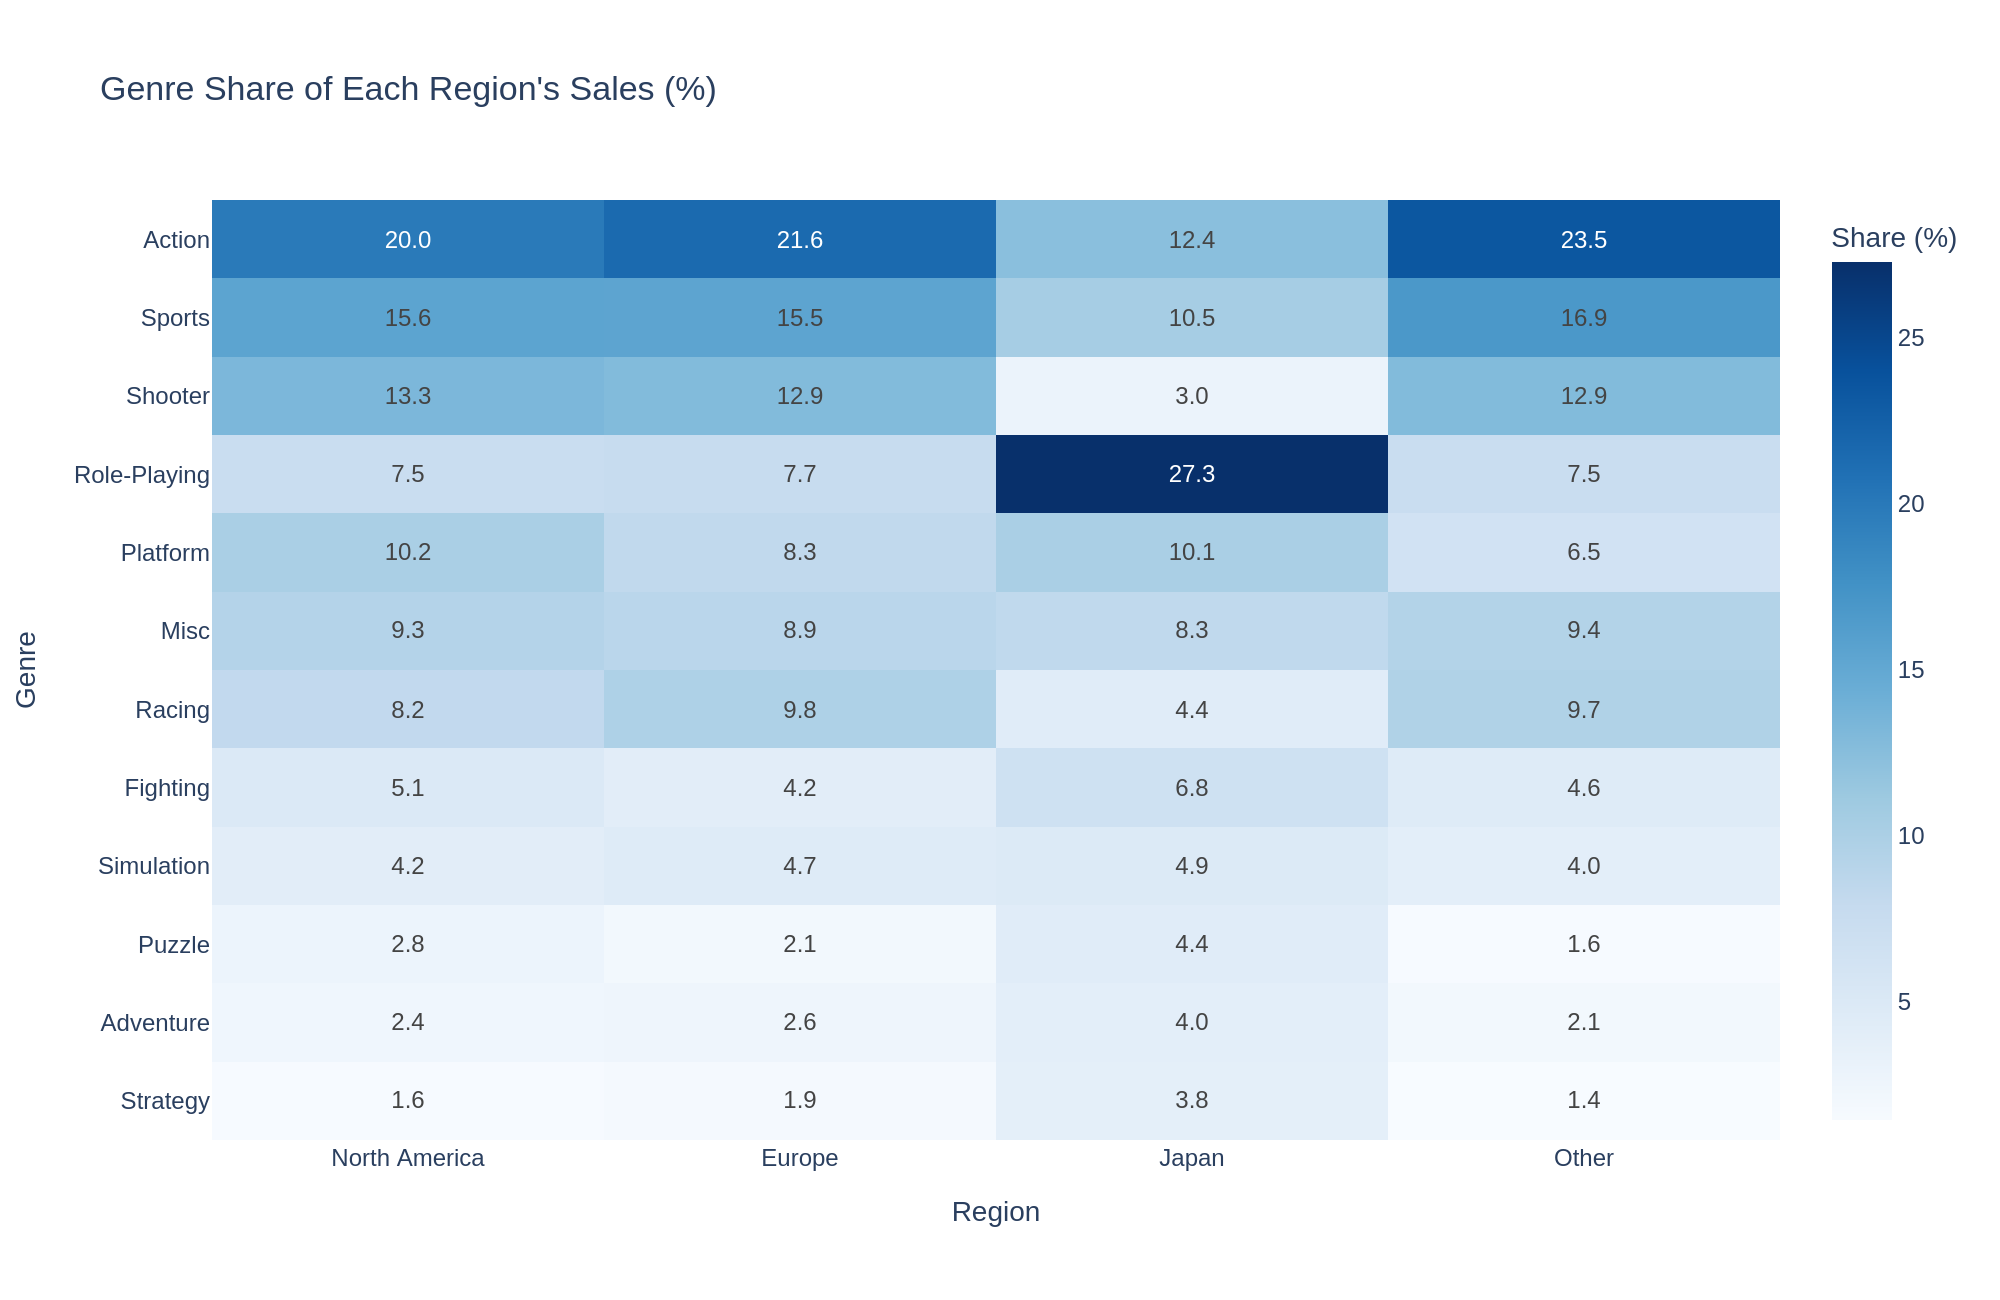

In [27]:
fig_genre_share = px.imshow(
    genre_share,
    text_auto='.1f',
    aspect='auto',
    color_continuous_scale='Blues',
    title="Genre Share of Each Region's Sales (%)",
    labels={'x': 'Region', 'y': 'Genre', 'color': 'Share (%)'}
)

fig_genre_share.update_layout(template='plotly_white')
fig_genre_share.show()

In [28]:
for region in region_labels:
    top_genre = genre_share[region].idxmax()
    top_value = genre_share[region].max()
    print(f'{region}: {top_genre} ({top_value:.1f}% of regional sales)')

North America: Action (20.0% of regional sales)
Europe: Action (21.6% of regional sales)
Japan: Role-Playing (27.3% of regional sales)
Other: Action (23.5% of regional sales)


**Result**

- `Action` is the number 1 genre in North America (20.0%), Europe (21.6%) and Other (23.5%)
- Japan is different: `Role-Playing` is **27.3%** of sales, against about 7.5% in the other 3 regions
- `Shooter` is only **3.0%** in Japan, but 12.9–13.3% everywhere else
- `Puzzle`, `Strategy` and `Adventure` have a higher share in Japan than in the other regions (4.4%, 3.8% and 4.0%), though all three are small genres

## Platform by region

In [29]:
platform_region = data.groupby('platform')[regions + ['global_sales']].sum().rename(columns=region_names)
platform_region = platform_region.sort_values('global_sales', ascending=False)

top_platforms = platform_region.head(10)
top_platforms.round(1)

,North America,Europe,Japan,Other,global_sales
platform,,,,,
PS2,583.8,339.3,139.2,193.4,1255.6
X360,601.0,280.6,12.4,85.5,980.0
PS3,392.3,343.7,80.0,141.9,957.8
Wii,507.7,268.4,69.4,80.6,926.7
DS,390.7,194.6,175.6,60.5,822.5
PS,336.5,213.6,139.8,40.9,730.7
GBA,187.5,75.2,47.3,7.7,318.5
PSP,109.0,68.2,76.8,42.2,296.3
PS4,96.8,123.7,14.3,43.4,278.1


In [30]:
platform_share = top_platforms[region_labels].div(top_platforms[region_labels].sum(axis=1), axis=0) * 100

platform_share.round(1)

,North America,Europe,Japan,Other
platform,,,,
PS2,46.5,27.0,11.1,15.4
X360,61.4,28.6,1.3,8.7
PS3,41.0,35.9,8.4,14.8
Wii,54.8,29.0,7.5,8.7
DS,47.6,23.7,21.4,7.4
PS,46.0,29.2,19.1,5.6
GBA,59.0,23.7,14.9,2.4
PSP,36.8,23.0,25.9,14.2
PS4,34.8,44.5,5.1,15.6


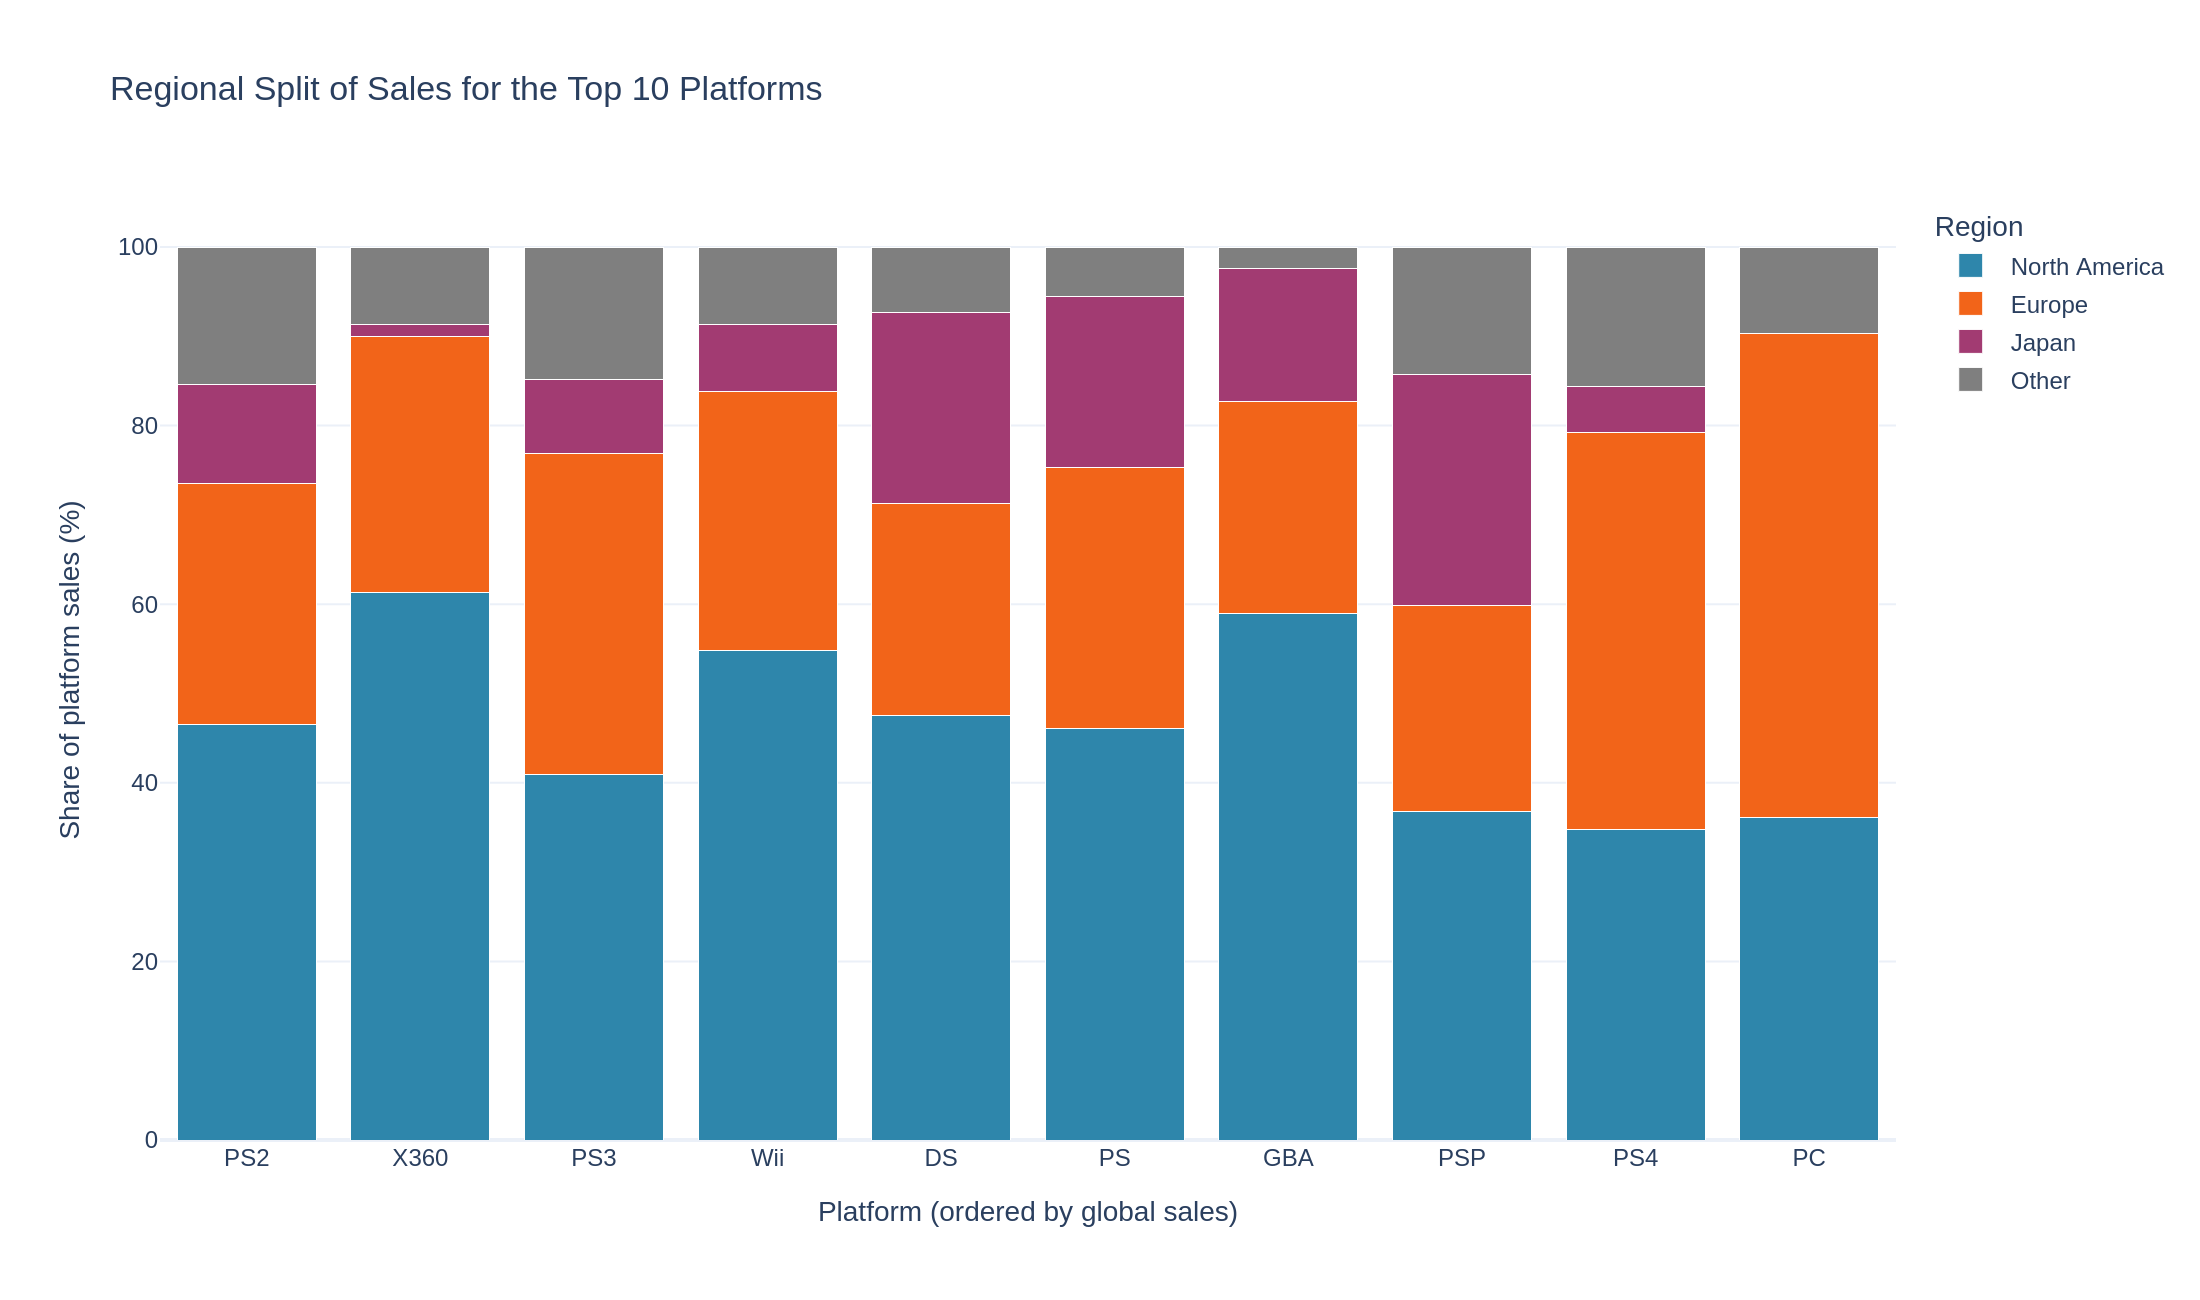

In [31]:
platform_long = platform_share.reset_index().melt(id_vars='platform', var_name='region', value_name='share_pct')

fig_platform = px.bar(
    platform_long,
    x='platform',
    y='share_pct',
    color='region',
    barmode='stack',
    color_discrete_map=region_colors,
    category_orders={'platform': top_platforms.index.tolist()},
    title='Regional Split of Sales for the Top 10 Platforms',
    labels={'platform': 'Platform (ordered by global sales)', 'share_pct': 'Share of platform sales (%)', 'region': 'Region'}
)

fig_platform.update_layout(template='plotly_white')
fig_platform.show()

In [32]:
for region in region_labels:
    top3 = platform_region[region].nlargest(3).round(1)
    print(f'{region}:', top3.to_dict())

North America: {'X360': 601.0, 'PS2': 583.8, 'Wii': 507.7}
Europe: {'PS3': 343.7, 'PS2': 339.3, 'X360': 280.6}
Japan: {'DS': 175.6, 'PS': 139.8, 'PS2': 139.2}
Other: {'PS2': 193.4, 'PS3': 141.9, 'X360': 85.5}


In [33]:
# Top-10 filter can hide Japan-heavy platforms, so rank ALL platforms with a minimum total (small-sample guard)
min_total = 100

platform_share_all = platform_region[region_labels].div(platform_region[region_labels].sum(axis=1), axis=0) * 100
big_platforms = platform_region[platform_region[region_labels].sum(axis=1) >= min_total].index

print(f'Platforms with at least {min_total}M units in total: {len(big_platforms)}')
platform_share_all.loc[big_platforms, 'Japan'].sort_values(ascending=False).round(1).head(5)

Platforms with at least 100M units in total: 18


platform
SNES    58.3
3DS     39.4
NES     39.3
GB      33.3
PSP     25.9
Name: Japan, dtype: float64

**Result**

- Biggest platform per region: `X360` in North America (601.0M), `PS3` in Europe (343.7M), `DS` in Japan (175.6M) and `PS2` in Other (193.4M)
- `X360` is 61.4% North America and only 1.3% Japan
- `PC` is **54.1%** Europe and almost zero in Japan (0.1%); `PS4` is also stronger in Europe (44.5%) than in North America (34.8%)
- Among the **top 10 platforms**, Japan's share is highest on `PSP` (25.9%) and `DS` (21.4%)
- Ranking **all** 18 platforms with at least 100M units puts Nintendo systems first by Japan share: `SNES` 58.3%, `3DS` 39.4%, `NES` 39.3%, `GB` 33.3%, then `PSP` 25.9%. The top-10 chart alone hides this
- Platform shares also reflect availability (a platform that was not sold in a region cannot sell there), not only taste

## Publisher by region

In [34]:
publisher_region = data.groupby('publisher')[regions].sum().rename(columns=region_names)

top_publishers = []

for region in region_labels:
    top5 = publisher_region[region].nlargest(5).reset_index()
    top5.columns = ['publisher', 'sales']
    top5['region'] = region
    top5['share_pct'] = (top5['sales'] / publisher_region[region].sum() * 100).round(1)
    top_publishers.append(top5)

top_publishers = pd.concat(top_publishers, ignore_index=True)
top_publishers['sales'] = top_publishers['sales'].round(1)

top_publishers

,publisher,sales,region,share_pct
0,Nintendo,816.9,North America,18.6
1,Electronic Arts,595.1,North America,13.5
2,Activision,429.7,North America,9.8
3,Sony Computer Entertainment,265.2,North America,6.0
4,Ubisoft,253.4,North America,5.8
5,Nintendo,418.7,Europe,17.2
6,Electronic Arts,371.3,Europe,15.3
7,Activision,215.5,Europe,8.9
8,Sony Computer Entertainment,187.7,Europe,7.7
9,Ubisoft,163.3,Europe,6.7


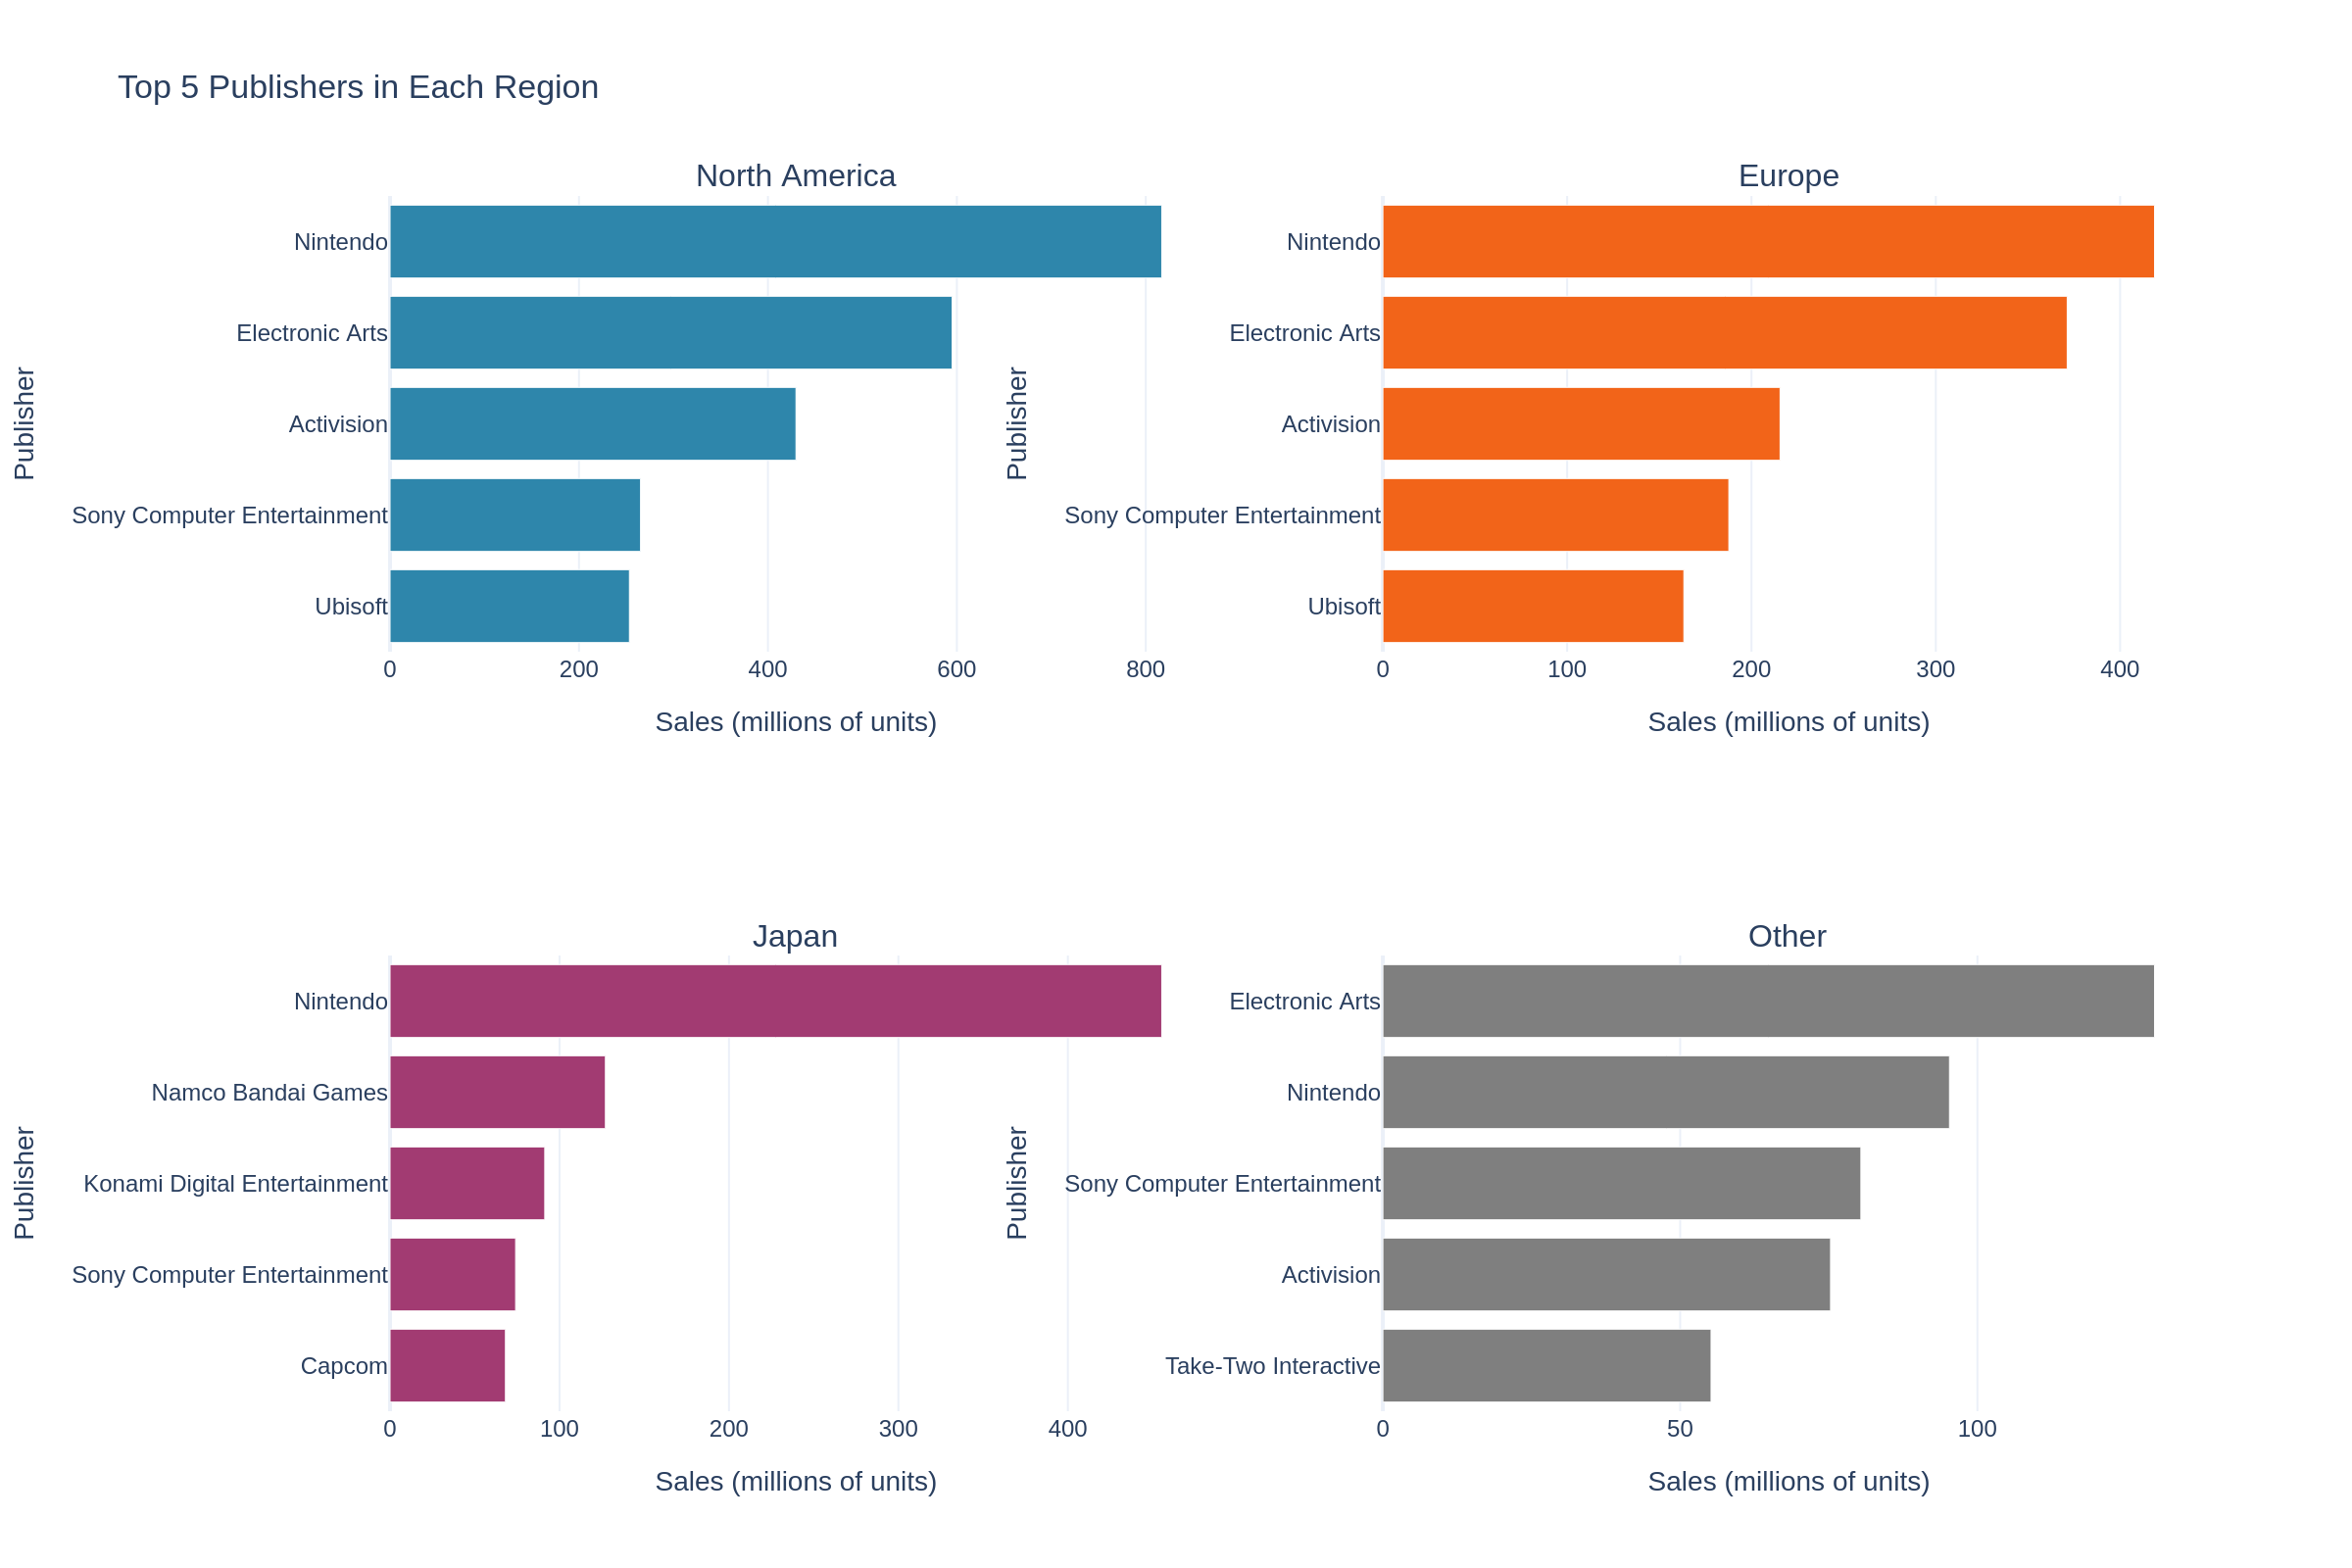

In [35]:
fig_publisher = make_subplots(rows=2, cols=2, subplot_titles=region_labels)

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for region, (row, col) in zip(region_labels, positions):
    part = top_publishers[top_publishers['region'] == region].sort_values('sales')
    fig_publisher.add_trace(
        go.Bar(x=part['sales'], y=part['publisher'], orientation='h', marker_color=region_colors[region]),
        row=row, col=col
    )

fig_publisher.update_xaxes(title_text='Sales (millions of units)')
fig_publisher.update_yaxes(title_text='Publisher')
fig_publisher.update_layout(title='Top 5 Publishers in Each Region', template='plotly_white', showlegend=False, height=700)
fig_publisher.show()

**Result**

- `Nintendo` is number 1 in North America (816.9M, 18.6%), Europe (418.7M, 17.2%) and Japan (455.4M, **35.3%**)
- `Electronic Arts` is number 2 in North America and Europe, and number 1 in Other (16.3%)
- In Japan the next publishers after Nintendo are `Namco Bandai Games` (9.8%), `Konami Digital Entertainment` (7.1%), `Sony Computer Entertainment` (5.7%) and `Capcom` (5.3%). `Electronic Arts` and `Activision`, which are big in the West, are not in the Japan top 5

## Regional sales over time

Sales in this dataset are the **lifetime sales of each game**, grouped by the game's **release year** (not the year when the copy was sold).

Only **1980–2015** is used here (see the `Years` section above). The new DataFrame is called `data_trend`.

In [36]:
data_trend = data[(data['year'] >= 1980) & (data['year'] <= 2015)].copy()
data_trend['year'] = data_trend['year'].astype(int)

print(f'Rows used for trend analysis: {len(data_trend):,} of {len(data):,}')
print(f'Year range after filter     : {data_trend["year"].min()} - {data_trend["year"].max()}')

Rows used for trend analysis: 15,979 of 16,598
Year range after filter     : 1980 - 2015


In [37]:
year_region = data_trend.groupby('year')[regions].sum().rename(columns=region_names).reset_index()

year_region.tail(5)

,year,North America,Europe,Japan,Other
31,2011,241.06,167.44,53.04,54.39
32,2012,154.96,118.78,51.74,37.82
33,2013,154.77,125.80,47.59,39.82
34,2014,131.97,125.65,39.46,40.02
35,2015,102.82,97.71,33.72,30.01


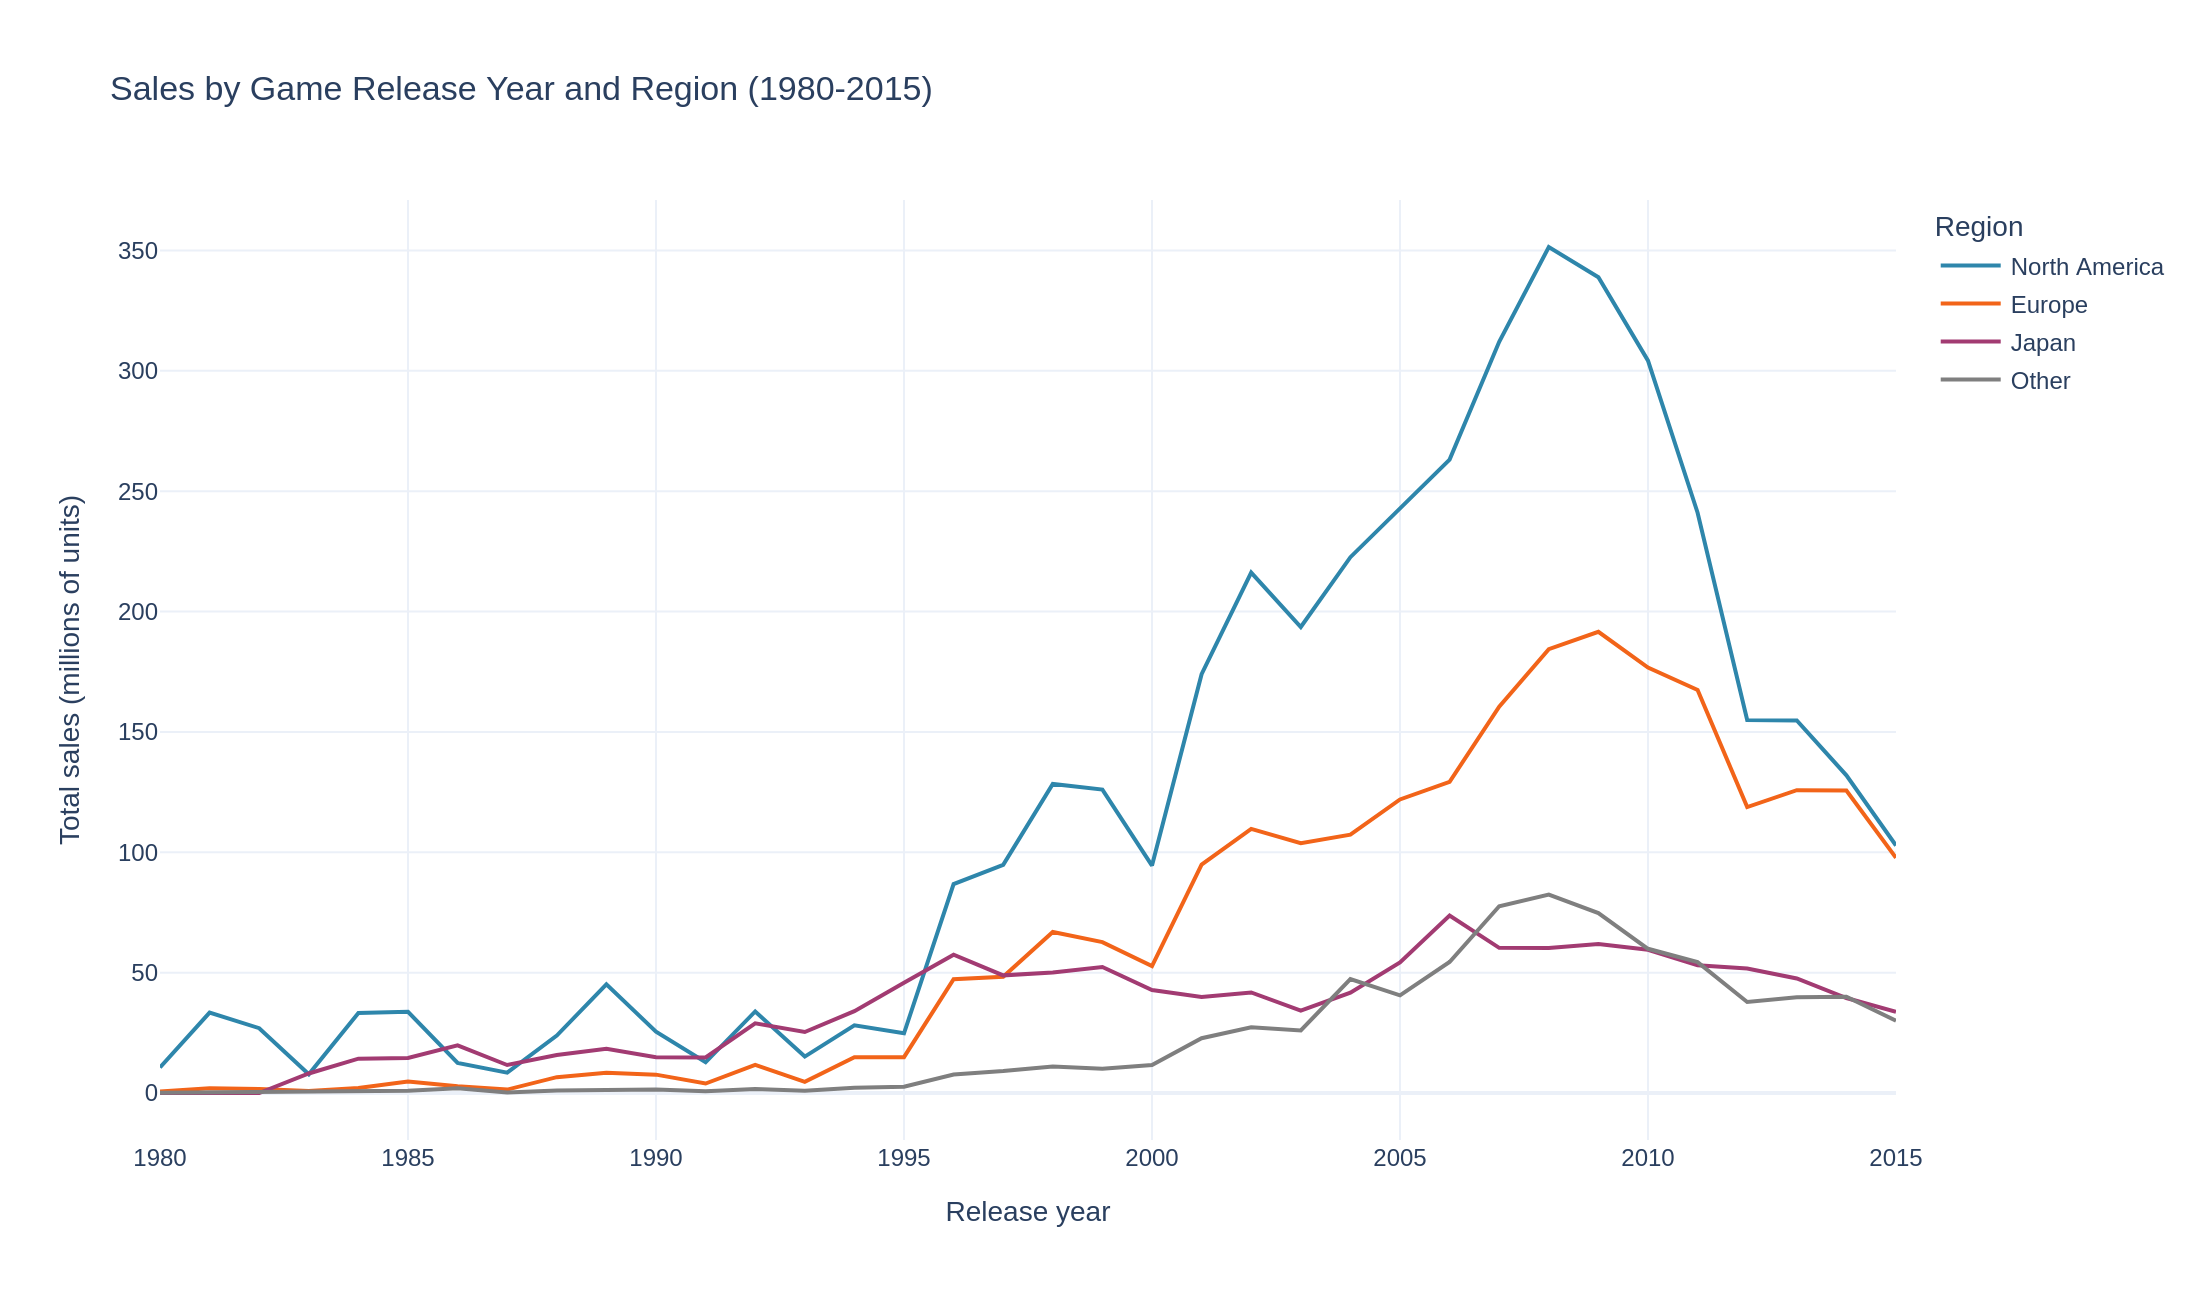

In [38]:
year_long = year_region.melt(id_vars='year', var_name='region', value_name='sales')

fig_year = px.line(
    year_long,
    x='year',
    y='sales',
    color='region',
    color_discrete_map=region_colors,
    title='Sales by Game Release Year and Region (1980-2015)',
    labels={'year': 'Release year', 'sales': 'Total sales (millions of units)', 'region': 'Region'}
)

fig_year.update_layout(template='plotly_white')
fig_year.show()

In [39]:
for region in region_labels:
    peak_year = year_region.loc[year_region[region].idxmax(), 'year']
    peak_value = year_region[region].max()
    print(f'{region}: peak year {peak_year} with {peak_value:,.1f}M units')

North America: peak year 2008 with 351.4M units
Europe: peak year 2009 with 191.6M units
Japan: peak year 2006 with 73.7M units
Other: peak year 2008 with 82.4M units


**Result** — North America, Europe and Other peak around 2008–2009, then fall. Japan peaks earlier, in 2006, and at a much lower level (73.7M compared with 351.4M in North America).

The drop after 2009 should not be read as a market collapse. This file has no information about digital sales, and the newest games have had less time to collect sales, so the late years may be undercounted.

### Regional share by decade

In [40]:
data_trend['decade'] = (data_trend['year'] // 10) * 10

decade_region = data_trend.groupby('decade')[regions].sum().rename(columns=region_names)
decade_share = (decade_region.div(decade_region.sum(axis=1), axis=0) * 100).round(1)

decade_share

,North America,Europe,Japan,Other
decade,,,,
1980,62.6,8.3,27.2,1.9
1990,45.1,22.1,29.1,3.7
2000,51.9,27.1,11.0,10.0
2010,44.5,33.2,11.6,10.7


In [41]:
decade_counts = data_trend.groupby('decade').agg(
    rows=('rank', 'size'),
    total_sales=('global_sales', 'sum')
).round(1)

decade_counts

,rows,total_sales
decade,,
1980,205,376.6
1990,1769,1278.9
2000,9208,4644.0
2010,4797,2449.6


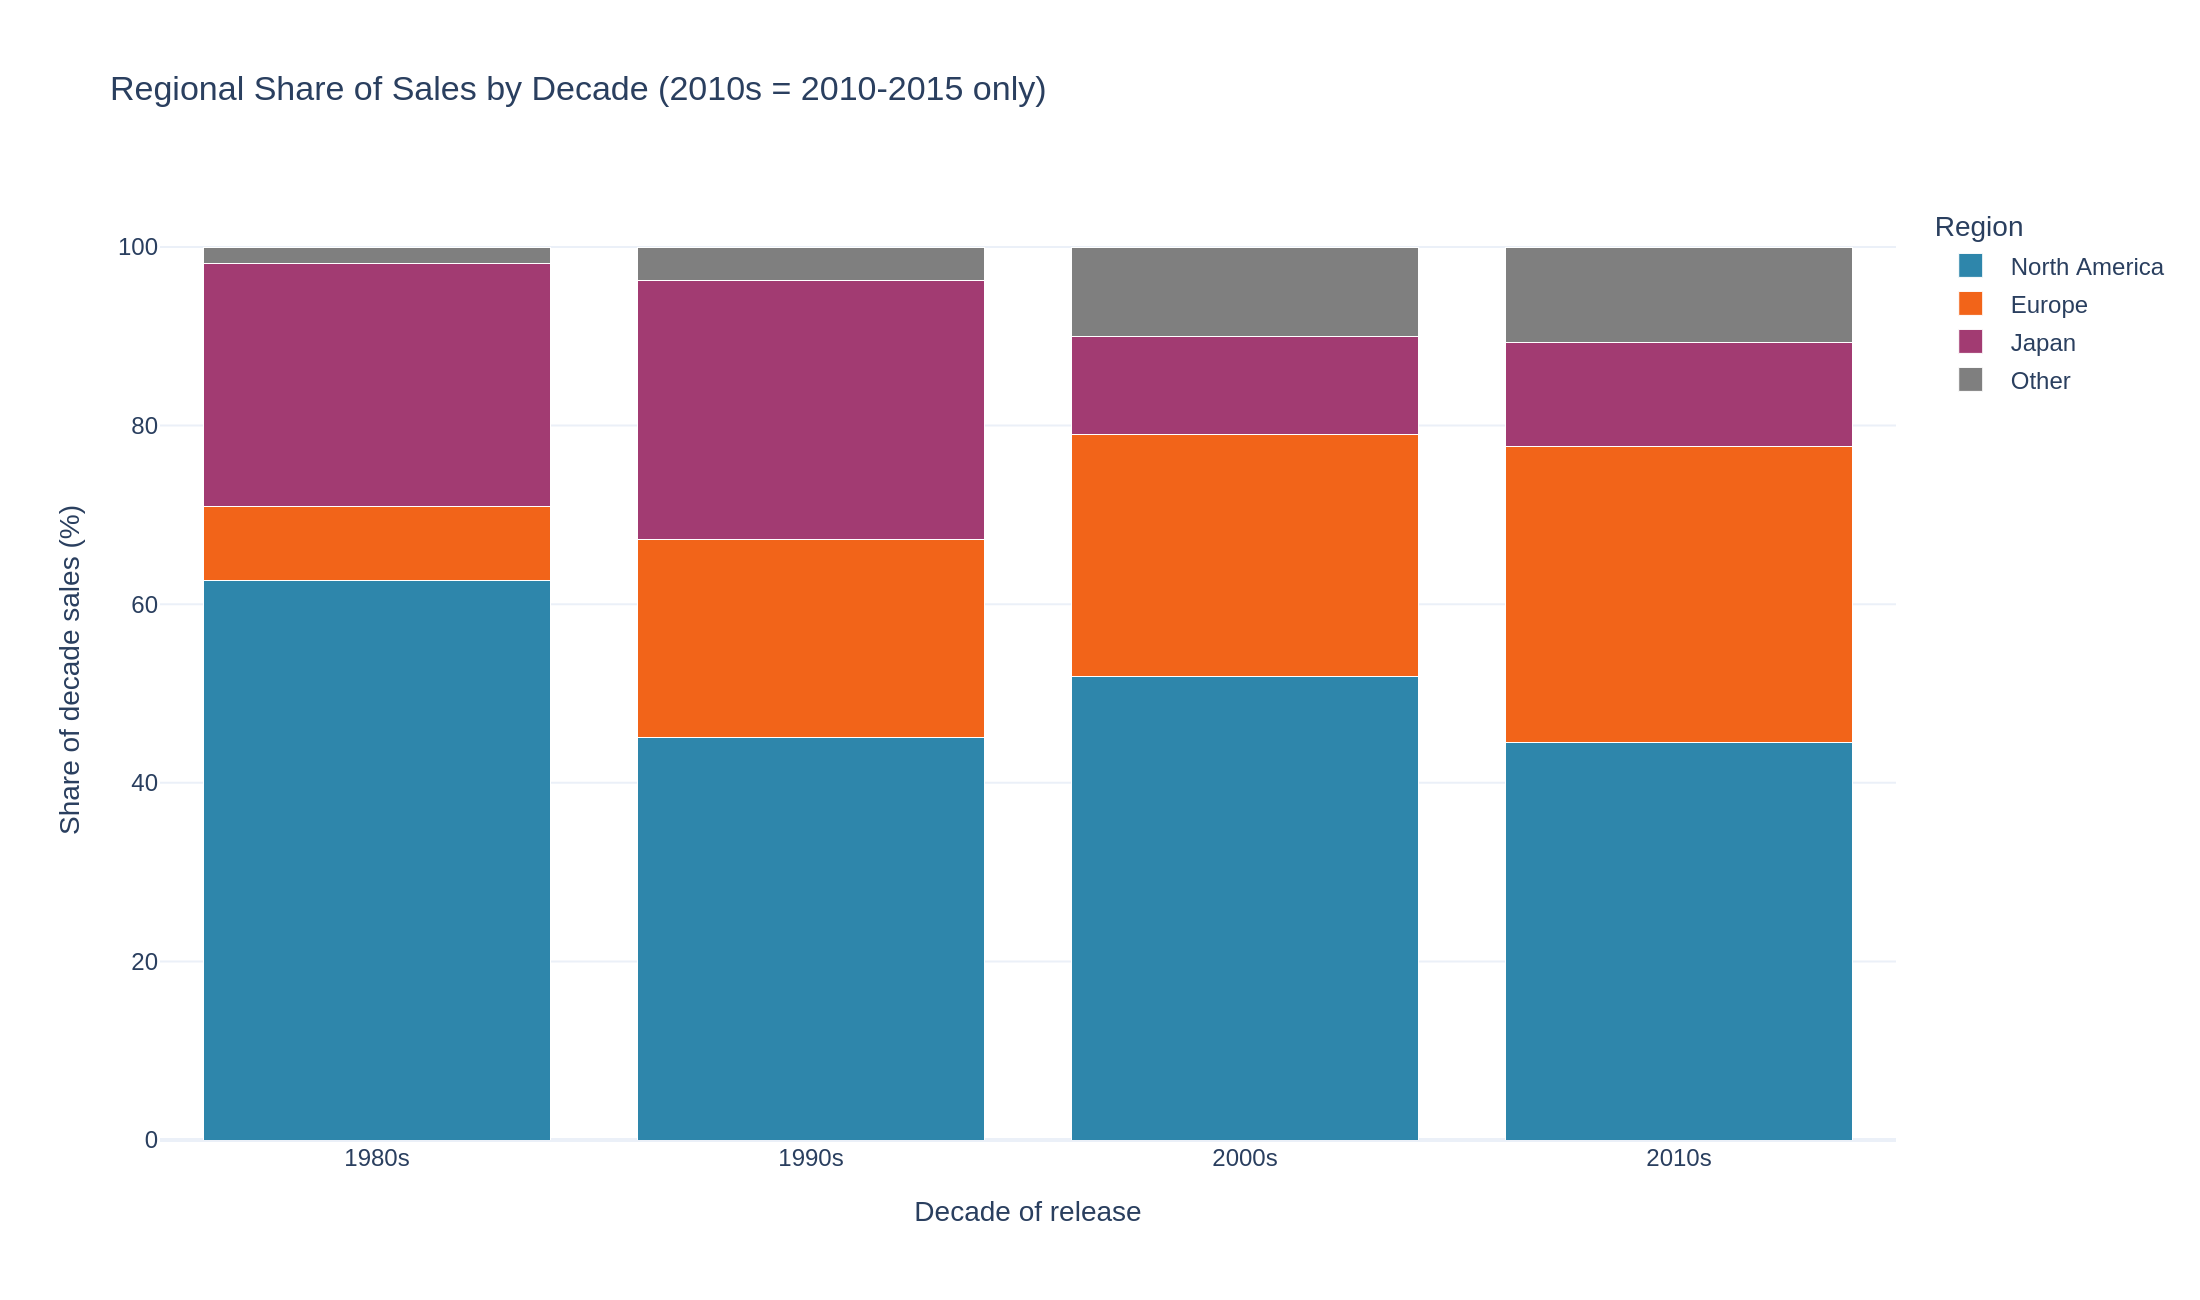

In [42]:
decade_long = decade_share.reset_index().melt(id_vars='decade', var_name='region', value_name='share_pct')
decade_long['decade'] = decade_long['decade'].astype(str) + 's'

fig_decade = px.bar(
    decade_long,
    x='decade',
    y='share_pct',
    color='region',
    barmode='stack',
    color_discrete_map=region_colors,
    title='Regional Share of Sales by Decade (2010s = 2010-2015 only)',
    labels={'decade': 'Decade of release', 'share_pct': 'Share of decade sales (%)', 'region': 'Region'}
)

fig_decade.update_layout(template='plotly_white')
fig_decade.show()

**Result**

- North America stays the biggest region in every decade (62.6% in the 1980s, 44.5% in 2010–2015)
- **Europe grows every decade**: 8.3% → 22.1% → 27.1% → 33.2%
- **Japan falls** from 27.2% and 29.1% (1980s and 1990s) to 11.0% in the 2000s, then stays flat at 11.6% in 2010–2015
- `Other` grows from 1.9% to 10.7%

> **Caution:** the 1980s are a small base (see the row counts and total sales per decade above). The early Europe and Other shares may partly reflect how well the source tracked those regions, not only the real market size. This file cannot separate the two, so the long-run Europe trend is a **hypothesis**, not a proven market shift.

## Top games by region

In [43]:
for region_column in regions:
    print(f'--- Top 5 games in {region_names[region_column]} ---')
    top_games = data.nlargest(5, region_column)[['name', 'platform', 'year', 'publisher', region_column]]
    display(top_games.reset_index(drop=True))

--- Top 5 games in North America ---


,name,platform,year,publisher,na_sales
0,Wii Sports,Wii,2006.0,Nintendo,41.49
1,Super Mario Bros.,NES,1985.0,Nintendo,29.08
2,Duck Hunt,NES,1984.0,Nintendo,26.93
3,Tetris,GB,1989.0,Nintendo,23.20
4,Mario Kart Wii,Wii,2008.0,Nintendo,15.85


--- Top 5 games in Europe ---


,name,platform,year,publisher,eu_sales
0,Wii Sports,Wii,2006.0,Nintendo,29.02
1,Mario Kart Wii,Wii,2008.0,Nintendo,12.88
2,Wii Sports Resort,Wii,2009.0,Nintendo,11.01
3,Nintendogs,DS,2005.0,Nintendo,11.00
4,Grand Theft Auto V,PS3,2013.0,Take-Two Interactive,9.27


--- Top 5 games in Japan ---


,name,platform,year,publisher,jp_sales
0,Pokemon Red/Pokemon Blue,GB,1996.0,Nintendo,10.22
1,Pokemon Gold/Pokemon Silver,GB,1999.0,Nintendo,7.20
2,Super Mario Bros.,NES,1985.0,Nintendo,6.81
3,New Super Mario Bros.,DS,2006.0,Nintendo,6.50
4,Pokemon Diamond/Pokemon Pearl,DS,2006.0,Nintendo,6.04


--- Top 5 games in Other ---


,name,platform,year,publisher,other_sales
0,Grand Theft Auto: San Andreas,PS2,2004.0,Take-Two Interactive,10.57
1,Wii Sports,Wii,2006.0,Nintendo,8.46
2,Gran Turismo 4,PS2,2004.0,Sony Computer Entertainment,7.53
3,Grand Theft Auto V,PS3,2013.0,Take-Two Interactive,4.14
4,Mario Kart Wii,Wii,2008.0,Nintendo,3.31


**Result**

- `Wii Sports` is number 1 in North America (41.49M), Europe (29.02M) and is number 2 in Other (8.46M)
- Japan's top 5 has `Pokemon` in 3 places (`Pokemon Red/Pokemon Blue` 10.22M, `Pokemon Gold/Pokemon Silver` 7.20M, `Pokemon Diamond/Pokemon Pearl` 6.04M) and `Super Mario` in the other 2. It is not led by the global bestsellers
- `Grand Theft Auto: San Andreas` is number 1 in Other (10.57M)

> **Note:** one row = one game on one platform, so a multi-platform game (for example `Grand Theft Auto V`) is split across rows and each row is ranked separately. These are game-platform rankings, not game rankings.

## Relationship between regions

In [44]:
region_sales = data[regions].rename(columns=region_names)

# Spearman: sales are right-skewed (mean >> median), so a rank-based correlation is used
corr = region_sales.corr(method='spearman').round(2)
corr_pearson = region_sales.corr().round(2)

print('Spearman:')
display(corr)
print('Pearson (for comparison):')
display(corr_pearson)

Spearman:


,North America,Europe,Japan,Other
North America,1.00,0.68,-0.23,0.77
Europe,0.68,1.00,-0.18,0.77
Japan,-0.23,-0.18,1.00,-0.07
Other,0.77,0.77,-0.07,1.00


Pearson (for comparison):


,North America,Europe,Japan,Other
North America,1.00,0.77,0.45,0.63
Europe,0.77,1.00,0.44,0.73
Japan,0.45,0.44,1.00,0.29
Other,0.63,0.73,0.29,1.00


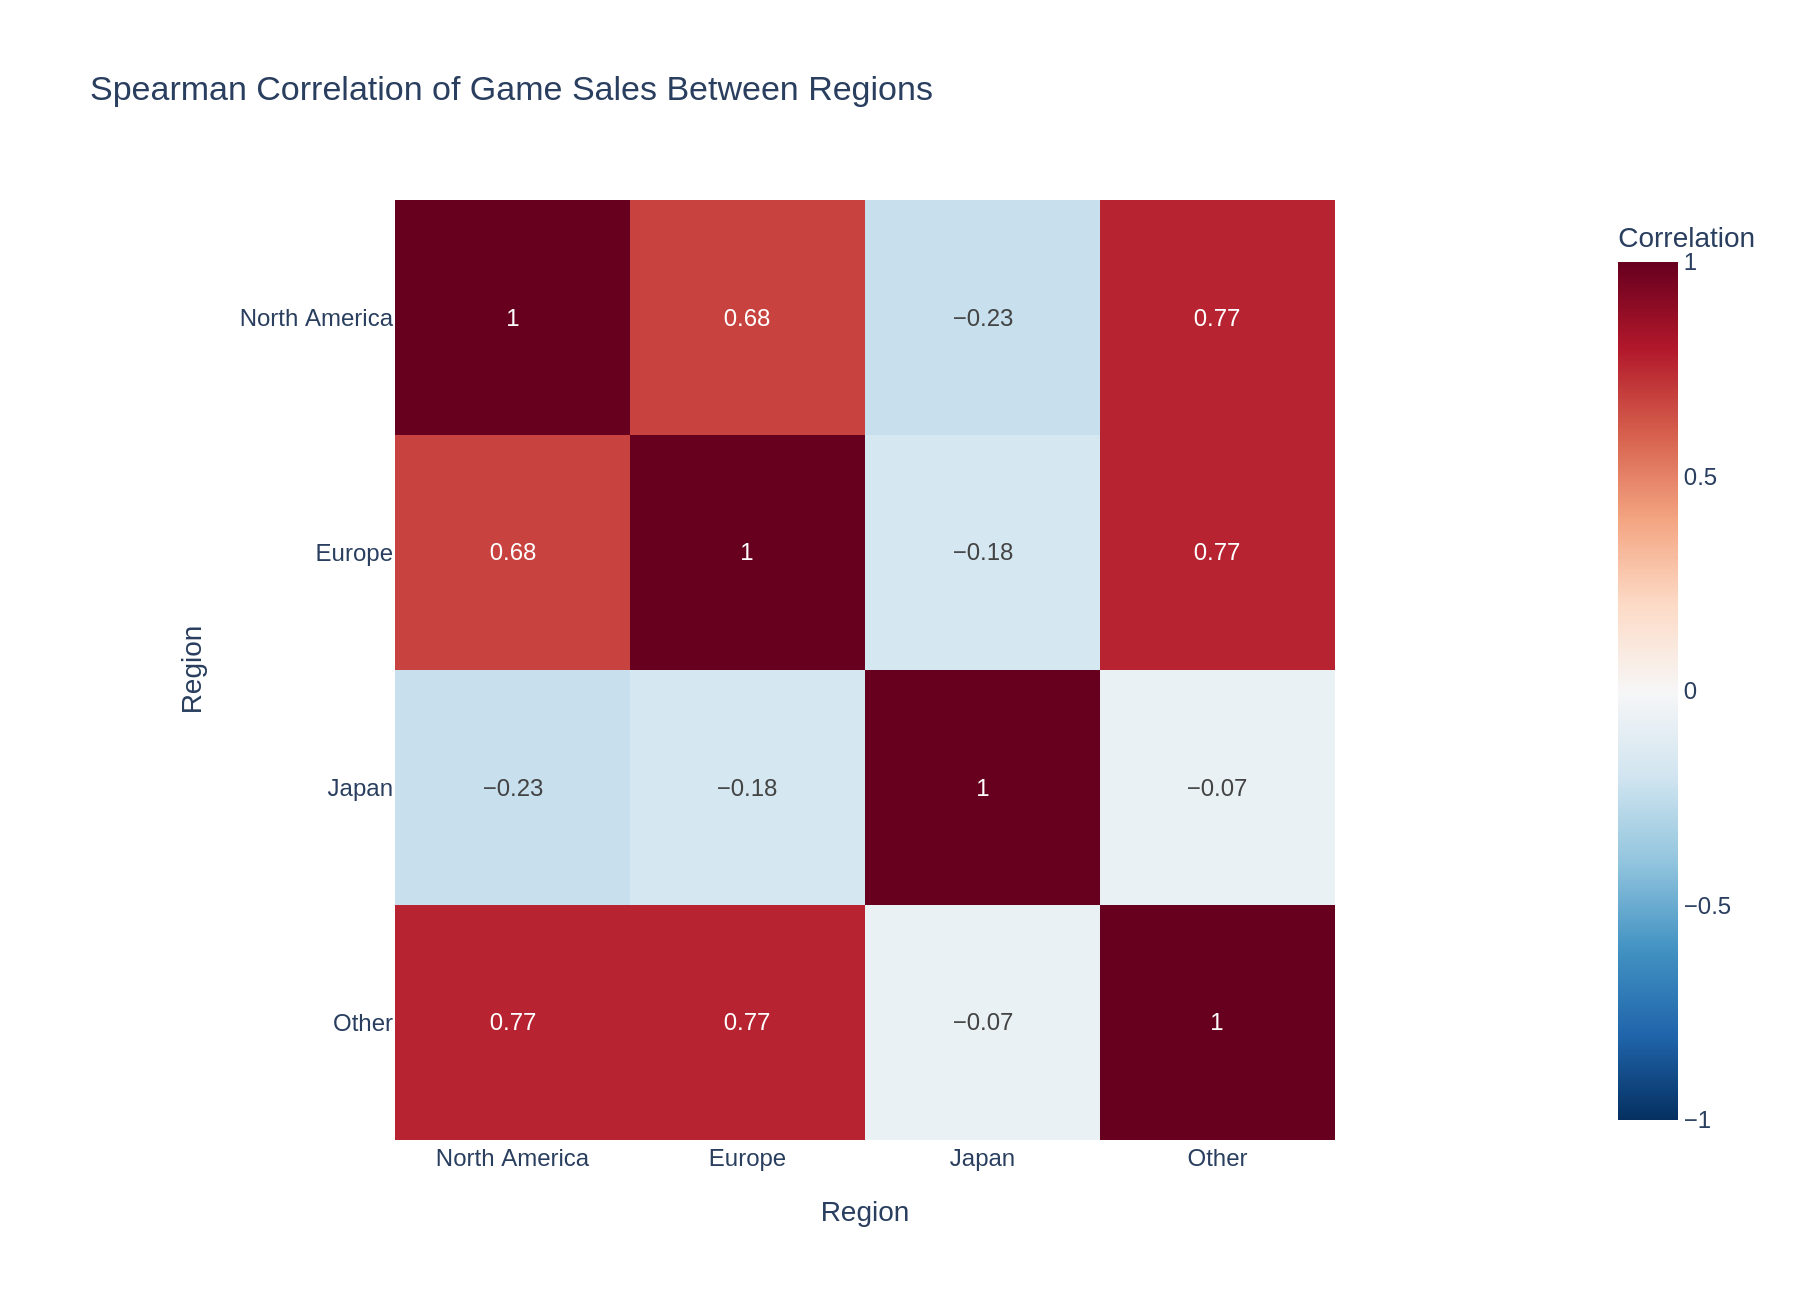

In [45]:
fig_corr = px.imshow(
    corr,
    text_auto=True,
    zmin=-1,
    zmax=1,
    color_continuous_scale='RdBu_r',
    title='Spearman Correlation of Game Sales Between Regions',
    labels={'x': 'Region', 'y': 'Region', 'color': 'Correlation'}
)

fig_corr.update_layout(template='plotly_white')
fig_corr.show()

In [46]:
pair_rows = []
for a, b in [('North America', 'Europe'), ('North America', 'Japan'), ('North America', 'Other'),
             ('Europe', 'Japan'), ('Europe', 'Other'), ('Japan', 'Other')]:
    both = region_sales[(region_sales[a] > 0) & (region_sales[b] > 0)]
    pair_rows.append({'pair': f'{a} - {b}', 'games_sold_in_both': len(both),
                      'spearman_sold_in_both': round(both[a].corr(both[b], method='spearman'), 2)})

display(pd.DataFrame(pair_rows))

na_only = ((region_sales['North America'] > 0) & (region_sales['Japan'] == 0)).sum()
jp_only = ((region_sales['Japan'] > 0) & (region_sales['North America'] == 0)).sum()
print(f'North America > 0 and Japan = 0.00: {na_only:,} games | Japan > 0 and North America = 0.00: {jp_only:,} games')

,pair,games_sold_in_both,spearman_sold_in_both
0,North America - Europe,9744,0.68
1,North America - Japan,2685,0.21
2,North America - Other,9341,0.67
3,Europe - Japan,2524,0.13
4,Europe - Other,8544,0.76
5,Japan - Other,2843,0.02


North America > 0 and Japan = 0.00: 9,414 games | Japan > 0 and North America = 0.00: 3,458 games


**Result** — Pearson suggests all regions move together (0.29–0.77), but **Spearman**, the right choice for skewed sales, shows a different picture for Japan.

- North America, Europe and Other are positively related: Spearman **0.68–0.77** (`Other` is closest to both: 0.77 with North America and 0.77 with Europe)
- Japan is **negatively** related to every other region: −0.23 with North America, −0.18 with Europe, −0.07 with Other

The negative values come mostly from zeros: Japan has 63.0% of games at `0.00`, so the rank correlation compares many tied zeros. The table above keeps only games with sales above 0 in **both** regions. There, Japan's Spearman is 0.21 with North America (2,685 games), 0.13 with Europe and 0.02 with Other, while the three Western-market pairs stay at 0.67–0.76.

**Fact:** among games sold in both regions, hits in North America, Europe and Other overlap strongly; Japan's overlap with them is weak. 9,414 games have North America sales but `0.00` in Japan, and 3,458 have Japan sales but `0.00` in North America.

**Interpretation:** many titles are probably specific to one market (released or marketed there only). The file has no release-region column, so this is not tested.

> **Note:** correlation is not causation. This only shows how hits overlap between regions; it does not say *why* (publisher marketing, platform availability and taste can all play a part).

## Regional profile

In [47]:
profile_rows = []

for region_column in regions:
    region = region_names[region_column]
    peak_index = year_region[region].idxmax()

    profile_rows.append({
        'region': region,
        'total_sales_m': round(data[region_column].sum(), 1),
        'share_pct': round(data[region_column].sum() / data[regions].sum().sum() * 100, 1),
        'top_genre': genre_share[region].idxmax(),
        'top_platform': platform_region[region].idxmax(),
        'top_publisher': publisher_region[region].idxmax(),
        'peak_year': int(year_region.loc[peak_index, 'year'])
    })

regional_profile = pd.DataFrame(profile_rows)
regional_profile

,region,total_sales_m,share_pct,top_genre,top_platform,top_publisher,peak_year
0,North America,4393.0,49.3,Action,X360,Nintendo,2008
1,Europe,2434.1,27.3,Action,PS3,Nintendo,2009
2,Japan,1291.0,14.5,Role-Playing,DS,Nintendo,2006
3,Other,797.8,8.9,Action,PS2,Electronic Arts,2008


# Final Conclusion



### Key Findings



| # | Finding |
| - | ------- |
| 1 | The dataset has 16,598 games (one row per game and platform) and 11 columns. Sales are in millions of units |
| 2 | Missing values: `year` 271 rows (1.6%) and `publisher` 58 rows (0.3%). No fully duplicated rows |
| 3 | North America is 49.3% of sales, Europe 27.3%, Japan 14.5%, Other 8.9% (share of the 4-region total) |
| 4 | Sales are right-skewed in every region. 63.0% of games have `0.00` sales in Japan, against 27.1% in North America. The data cannot say whether those games were released there |
| 5 | `Action` leads in North America, Europe and Other. Japan leads with `Role-Playing` (27.3% of its sales) and has a very low `Shooter` share (3.0%). Action, Sports and Shooter are 46.2% of all sales |
| 6 | Platform mix is very different. `X360` is 61.4% North America and `PC` is 54.1% Europe. Japan's share is highest on Nintendo platforms: `SNES` 58.3%, `3DS` 39.4%, `NES` 39.3%, `GB` 33.3% (platforms with at least 100M units) |
| 7 | `Nintendo` is number 1 in North America, Europe and Japan (35.3% of Japan sales). `Electronic Arts` is number 1 in Other |
| 8 | Europe's share grows every decade (8.3% → 33.2%), while Japan's falls from about 29% (1990s) to about 11–12% (2000s and later). The 1980s are a small base, so this is a hypothesis |
| 9 | North America, Europe and Other overlap strongly (Spearman 0.68–0.77). Japan's Spearman is negative with all three (−0.23 to −0.07) because 63.0% of its values are `0.00`; among games sold in both regions it is weak (0.02–0.21). A hit in the West is a weaker signal for Japan |



### Regional Summary



| Region | Share of sales | Top genre | Top platform | Top publisher | Peak release year |
| ------ | -------------: | --------- | ------------ | ------------- | ----------------: |
| North America | 49.3% | Action | X360 | Nintendo | 2008 |
| Europe | 27.3% | Action | PS3 | Nintendo | 2009 |
| Japan | 14.5% | Role-Playing | DS | Nintendo | 2006 |
| Other | 8.9% | Action | PS2 | Electronic Arts | 2008 |


### Business Recommendations



**Portfolio mix**

- Weight a Japan line-up towards `Role-Playing` (27.3% of Japan sales vs about 7.5% elsewhere) and away from `Shooter` (3.0% vs 12.9–13.3%). Test it with a small pilot and compare Japan units per title against a Shooter-heavy control. The shares are descriptive and do not prove that genre causes the difference

**Platform strategy**

- For Europe-focused titles, test `PC` and `PS4` first (54.1% and 44.5% of their sales are in Europe, against 27.3% for the market as a whole). Platform shares also reflect availability, so check install base before acting

**Data**

- Before any Japan launch decision, get release-region data: 63.0% of games show `0.00` Japan sales and this file cannot tell "not released" from "released and sold very little"